<div style="padding: 30px; background-color: #121212; border-radius: 12px; border: 2px solid #333; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 8px 16px rgba(0,0,0,0.5);">
    <h1 style="color: #ffffff; text-align: center; font-size: 2.2em; margin-bottom: 5px;">🗳️ Indian Lok Sabha Election Analysis & Prediction</h1>
    <p style="color: #4da8da; text-align: center; font-size: 1.1em; margin-top: 0; font-weight: 500;">1962–2024 | INT557 — Data Science with Python | Session 2025–26</p>
    <hr style="border: 0; height: 1px; background: #333; margin: 20px 0;">
    <table style="width: 100%; color: #f0f0f0; font-size: 16px; border-collapse: collapse; line-height: 1.6;">
        <thead>
            <tr style="background-color: #16213e; border-bottom: 2px solid #4da8da;">
                <th style="padding: 12px; color: #ffffff; text-align: center; width: 5%;">#</th>
                <th style="padding: 12px; color: #ffffff; text-align: left; width: 35%;">Objective</th>
                <th style="padding: 12px; color: #ffffff; text-align: left; width: 60%;">Problem Statement</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #121212; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">1</td>
                <td style="padding: 12px; color: #ffffff;">Voter Turnout Analysis</td>
                <td style="padding: 12px; color: #cccccc;">How has voter participation changed 1962–2024?</td>
            </tr>
            <tr style="background-color: #1a1a24; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">2</td>
                <td style="padding: 12px; color: #ffffff;">Party Dominance & Vote Share</td>
                <td style="padding: 12px; color: #cccccc;">How did BJP rise and INC fall from 1984–2024?</td>
            </tr>
            <tr style="background-color: #121212; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">3</td>
                <td style="padding: 12px; color: #ffffff;">Candidate Profile Analysis</td>
                <td style="padding: 12px; color: #cccccc;">Do criminal candidates win more? Does money & incumbency help?</td>
            </tr>
            <tr style="background-color: #1a1a24; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">4</td>
                <td style="padding: 12px; color: #ffffff;">Winning Margin & Swing Seats</td>
                <td style="padding: 12px; color: #cccccc;">Which seats are safe and which are swing?</td>
            </tr>
            <tr style="background-color: #121212; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">5</td>
                <td style="padding: 12px; color: #ffffff;">ML Model — Predicting Winners</td>
                <td style="padding: 12px; color: #cccccc;">Can a computer predict who will win using past data?</td>
            </tr>
            <tr style="background-color: #1a1a24; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">6</td>
                <td style="padding: 12px; color: #ffffff;">Delimitation + Women Seats After</td>
                <td style="padding: 12px; color: #cccccc;">How many women seats per state after 2027 delimitation?</td>
            </tr>
            <tr style="background-color: #121212; border-bottom: 1px solid #2a2a35;">
                <td style="padding: 12px; text-align: center; font-weight: bold; color: #4da8da;">7</td>
                <td style="padding: 12px; color: #ffffff;">Women's Reservation Analysis</td>
                <td style="padding: 12px; color: #cccccc;">Historical gap vs 33% target — party & state breakdown</td>
            </tr>
        </tbody>
    </table>
</div>

In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style — same as friend's project
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Party colours
COLORS = {
    'BJP':'#FF6B35', 'INC':'#4169E1', 'TMC':'#27AE60',
    'SP':'#E74C3C',  'BSP':'#8E44AD', 'Left':'#E67E22',
    'Independent':'#95A5A6', 'Others':'#BDC3C7'
}

print("Libraries ready!")

Libraries ready!


<div style="background:#17202a;padding:14px;border-radius:8px;border-left:8px solid #3498db;">
<h3 style="color:#3498db;">Step 2 — Load All Datasets</h3></div>

In [8]:
import pandas as pd

# Load all 6 datasets (Updated the df_main filename to match your folder)
df_main   = pd.read_csv('Loksabha_1962-2019_.csv', encoding='latin1')
df_2024   = pd.read_csv('eci_data_2024.csv', encoding='latin1')
df_m24    = pd.read_excel('GE_India_2024.xlsx')
df_aff    = pd.read_csv('2004-2019-affidavits.csv', encoding='latin1')
df_aff.rename(columns={df_aff.columns[0]: 'State'}, inplace=True)
df_census = pd.read_csv('Table_2A_State_Uts.csv', encoding='latin1')
df_phase  = pd.read_excel('phase_data.xlsx')
df_phase.columns = ['SNo','State','PC_Name','Electors','Poll_Pct','Votes']

print("All datasets loaded!")
for name, df in [('Main', df_main), ('2024', df_2024), ('Margins', df_m24),
                 ('Affidavit', df_aff), ('Census', df_census), ('Phase', df_phase)]:
    print(f"  {name:12s}: {df.shape[0]:,} rows x {df.shape[1]} cols")

All datasets loaded!
  Main        : 8,047 rows x 12 cols
  2024        : 8,902 rows x 9 cols
  Margins     : 544 rows x 9 cols
  Affidavit   : 27,447 rows x 23 cols
  Census      : 37 rows x 5 cols
  Phase       : 104 rows x 6 cols


<div style="background:#17202a;padding:14px;border-radius:8px;border-left:8px solid #f39c12;">
<h3 style="color:#f39c12;">Step 3 — Data Cleaning</h3></div>

In [9]:
# Clean main dataset
df_main['state'] = df_main['state'].str.replace(r'\s*\[.*?\]', '', regex=True).str.strip()
df_main['state'] = df_main['state'].replace('Laccadive, Minicoy And Amindivi Islands', 'Lakshadweep')

# Fix year to int first (it's stored as float — causes '1960.0s' bug)
df_main = df_main.dropna(subset=['year'])       # FIXED — drop rows with no year
df_main['year'] = df_main['year'].astype(int)   # FIXED — now safe to convert

# Fix turnout — stored as '54.5 %' string, strip to get numeric
df_main['turnout'] = pd.to_numeric(df_main['Turnout'].astype(str).str.replace('%','').str.strip(), errors='coerce')

# Fix margin and margin_pct — stored as '89,085' and '40.40%'
df_main['margin']     = pd.to_numeric(df_main['margin'].astype(str).str.replace(',',''), errors='coerce')
df_main['margin_pct'] = pd.to_numeric(df_main['margin%'].astype(str).str.replace('%','').str.strip(), errors='coerce')
df_main['decade']     = (df_main['year']//10*10).astype(str)+'s'  # now gives '1960s' not '1960.0s'

# Clean affidavit dataset
df_aff['Winner']         = pd.to_numeric(df_aff['Winner'], errors='coerce').fillna(0).astype(int)
df_aff['CriminalCases']  = pd.to_numeric(df_aff['CriminalCases'], errors='coerce').fillna(0)
df_aff['TotalAssets_Cr'] = pd.to_numeric(df_aff['TotalAssets'], errors='coerce').fillna(0) / 1e7
df_aff['Age']            = pd.to_numeric(df_aff['Age'], errors='coerce')
df_aff['Age']            = df_aff['Age'].fillna(df_aff['Age'].mean())
df_aff['HasCriminal']    = (df_aff['CriminalCases'] > 0).astype(int)
df_aff['Crorepati']      = (df_aff['TotalAssets_Cr'] >= 1).astype(int)
df_aff['ReturningCandidate'] = df_aff['ReturningCandidate'].apply(lambda x: 1 if str(x)=='1' else 0)

# Fix 2019 Winner column (missing in affidavit file)
winners_2019 = set(df_main[df_main['year']==2019]['candidate_name'].str.upper().str.strip())
mask_2019    = df_aff['Year']==2019
df_aff.loc[mask_2019,'Winner'] = df_aff.loc[mask_2019,'Candidate'].str.upper().str.strip().isin(winners_2019).astype(int)

# Clean 2024 data
df_2024['Total Votes'] = pd.to_numeric(df_2024['Total Votes'].astype(str).str.replace(',',''), errors='coerce')

# Party grouping function
def party_group(p):
    p = str(p).strip()
    if p in ('Bharatiya Janta Party','Bharatiya Janata Party'): return 'BJP'
    if p in ('Indian National Congress','Indian National Congress (I)'): return 'INC'
    if 'Trinamool' in p:     return 'TMC'
    if 'Samajwadi' in p:     return 'SP'
    if 'Bahujan Samaj' in p: return 'BSP'
    if 'Communist' in p or 'CPI' in p: return 'Left'
    if 'Independent' in p:   return 'Independent'
    return 'Others'

df_main['party_group'] = df_main['party'].apply(party_group)
df_2024['party_group'] = df_2024['Party'].apply(party_group)
df_aff['party_group']  = df_aff['Party'].apply(party_group)

print('Data cleaning complete!')
print('Turnout sample:', df_main['turnout'].head(3).tolist())
print('Margin % sample:', df_main['margin_pct'].head(3).tolist())
print('Decade values:', df_main['decade'].value_counts().sort_index().to_dict())

Data cleaning complete!
Turnout sample: [54.5, 60.2, 63.6]
Margin % sample: [40.4, 13.1, 19.7]
Decade values: {'1960s': 1014, '1970s': 1061, '1980s': 1629, '1990s': 2172, '2000s': 1086, '2010s': 1084}


<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #3498db;margin-top:10px;">
<h2 style="color:#3498db;">Objective 1: Voter Turnout Analysis</h2>
<p style="color:#ccc;"><b>Goal:</b> How has voter participation changed from 1962 to 2024? Which states vote most and least?</p></div>

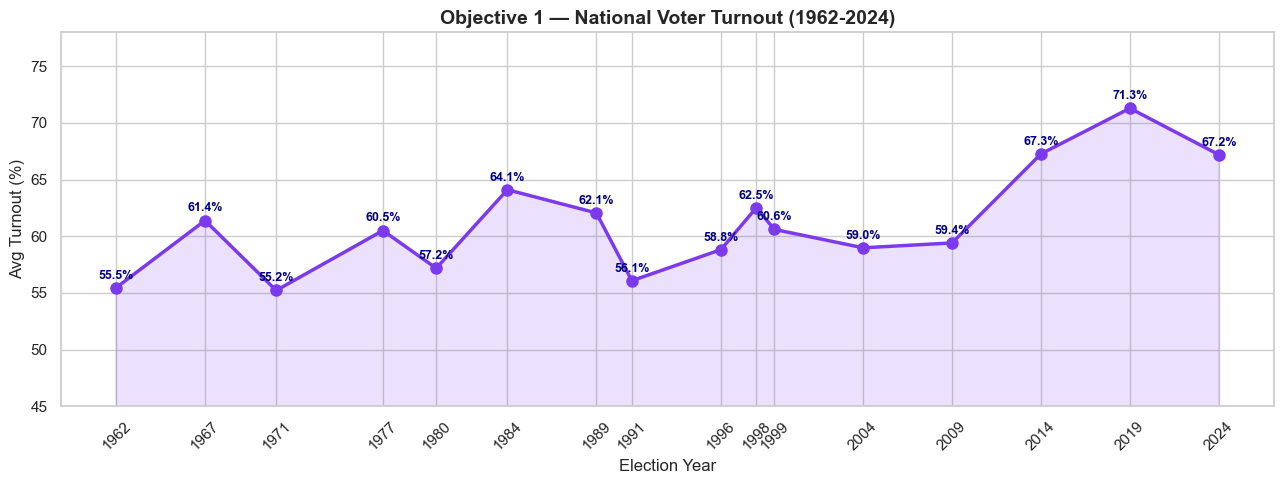

Finding: Turnout 55% (1962) se 66%+ (2024) tak badha — democracy mein participation badh rahi hai!


In [10]:
# National average turnout per year
turnout = df_main.groupby('year')['turnout'].mean().reset_index()
turnout.columns = ['Year','Avg_Turnout']
row2024 = pd.DataFrame({'Year':[2024], 'Avg_Turnout':[df_phase['Poll_Pct'].mean()]})
turnout = pd.concat([turnout, row2024], ignore_index=True)

# Chart 1.1 — National Turnout Trend
plt.figure(figsize=(13, 5))
plt.plot(turnout['Year'], turnout['Avg_Turnout'],
         color='#7c3aed', linewidth=2.5, marker='o', markersize=8)
plt.fill_between(turnout['Year'], turnout['Avg_Turnout'], alpha=0.15, color='#7c3aed')
for _, r in turnout.iterrows():
    plt.text(r['Year'], r['Avg_Turnout']+0.8, f"{r['Avg_Turnout']:.1f}%",
             ha='center', fontsize=9, fontweight='bold', color='navy')
plt.title('Objective 1 — National Voter Turnout (1962-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Election Year')
plt.ylabel('Avg Turnout (%)')
plt.ylim(45, 78)
plt.xticks(turnout['Year'], rotation=45)
plt.tight_layout()
plt.savefig('viz_1_1_turnout_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Turnout 55% (1962) se 66%+ (2024) tak badha — democracy mein participation badh rahi hai!")

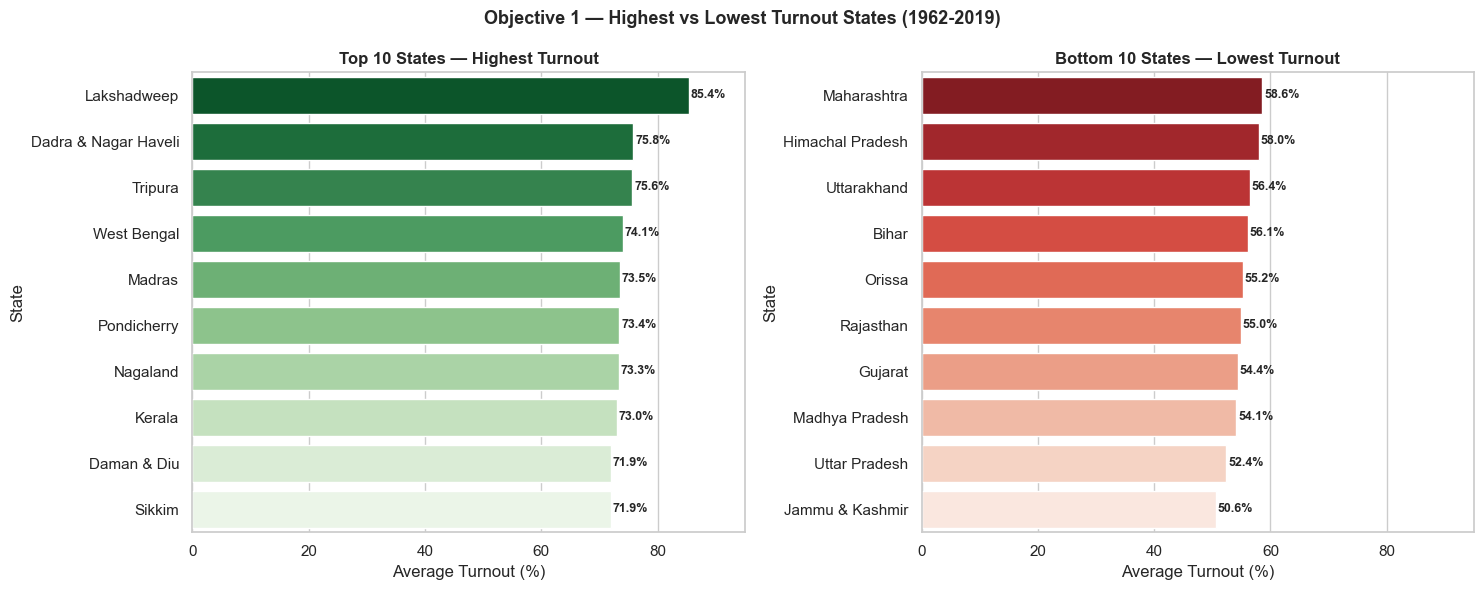

In [11]:
# Chart 1.2 — Top 10 vs Bottom 10 states
state_t = df_main.groupby('state')['turnout'].mean().dropna().reset_index()
state_t.columns = ['State','Turnout']
state_t = state_t.sort_values('Turnout', ascending=False)
top10 = state_t.head(10)
bot10 = state_t.tail(10)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Turnout', y='State', data=top10, palette='Greens_r')
for i, v in enumerate(top10['Turnout']):
    plt.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.title('Top 10 States — Highest Turnout', fontweight='bold')
plt.xlabel('Average Turnout (%)')
plt.xlim(0, 95)

plt.subplot(1, 2, 2)
sns.barplot(x='Turnout', y='State', data=bot10, palette='Reds_r')
for i, v in enumerate(bot10['Turnout']):
    plt.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.title('Bottom 10 States — Lowest Turnout', fontweight='bold')
plt.xlabel('Average Turnout (%)')
plt.xlim(0, 95)

plt.suptitle('Objective 1 — Highest vs Lowest Turnout States (1962-2019)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_1_2_states_turnout.png', dpi=120, bbox_inches='tight')
plt.show()

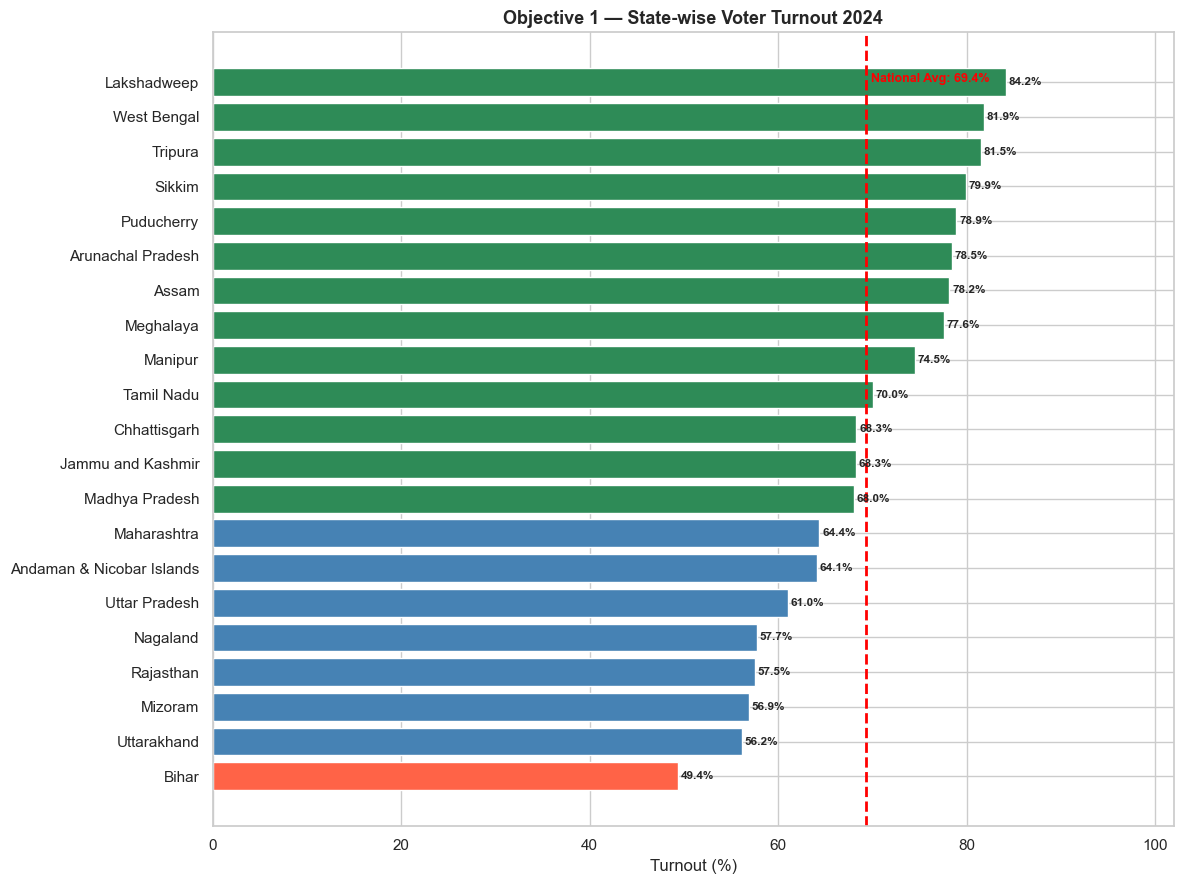

In [12]:
# Chart 1.3 — 2024 State-wise Turnout
s24 = df_phase.groupby('State')['Poll_Pct'].mean().reset_index()
s24['State'] = s24['State'].str.replace('\n',' ').str.strip()
s24 = s24.sort_values('Poll_Pct')
nat_avg = s24['Poll_Pct'].mean()

def pick_color(v):
    if v >= 65: return 'seagreen'
    if v >= 55: return 'steelblue'
    return 'tomato'

colors = [pick_color(v) for v in s24['Poll_Pct']]

plt.figure(figsize=(12, 9))
bars = plt.barh(s24['State'], s24['Poll_Pct'], color=colors, edgecolor='white')
for b in bars:
    plt.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
             f'{b.get_width():.1f}%', va='center', fontsize=8.5, fontweight='bold')
plt.axvline(x=nat_avg, color='red', linestyle='--', linewidth=2)
plt.text(nat_avg+0.5, len(s24)-1, f'National Avg: {nat_avg:.1f}%',
         color='red', fontsize=9, fontweight='bold')
plt.title('Objective 1 — State-wise Voter Turnout 2024', fontsize=13, fontweight='bold')
plt.xlabel('Turnout (%)')
plt.xlim(0, 102)
plt.tight_layout()
plt.savefig('viz_1_3_2024_turnout.png', dpi=120, bbox_inches='tight')
plt.show()

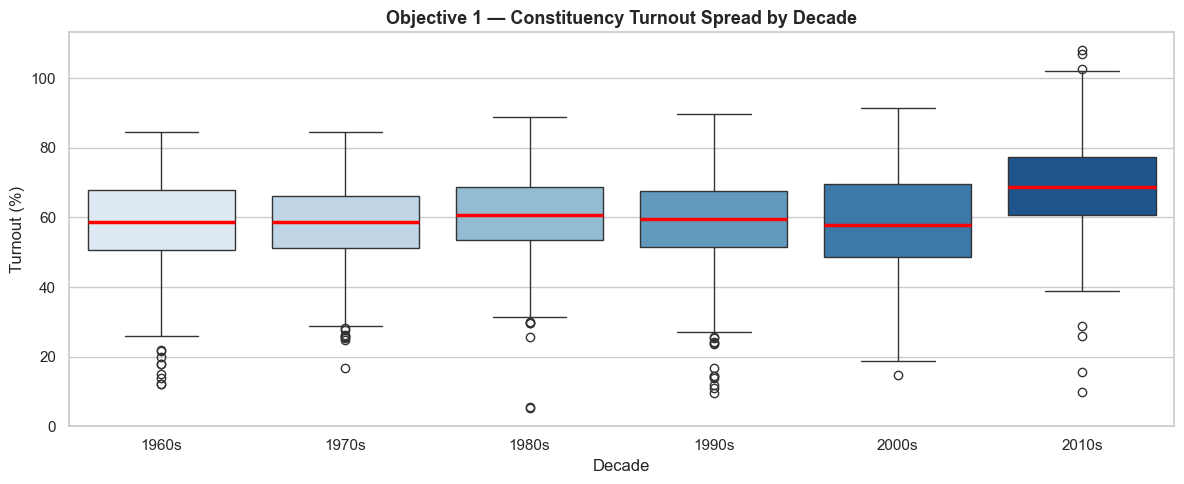

Finding: 2010s mein median turnout sabse high — India mein democratic participation growing hai.


In [13]:
# Chart 1.4 — Decade-wise Boxplot
decade_order = ['1960s','1970s','1980s','1990s','2000s','2010s']
df_dec = df_main[df_main['decade'].isin(decade_order)]

plt.figure(figsize=(12, 5))
sns.boxplot(x='decade', y='turnout', data=df_dec, order=decade_order,
            palette='Blues', medianprops={'color':'red','linewidth':2.5})
plt.title('Objective 1 — Constituency Turnout Spread by Decade', fontsize=13, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Turnout (%)')
plt.tight_layout()
plt.savefig('viz_1_4_decade_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: 2010s mein median turnout sabse high — India mein democratic participation growing hai.")

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #e74c3c;margin-top:10px;">
<h2 style="color:#e74c3c;">Objective 2: Party Dominance & Vote Share Shifts</h2>
<p style="color:#ccc;"><b>Goal:</b> BJP 2 seats (1984) se 303 (2019) tak kaisa badha? INC 414 se 52 tak kaisa gira?</p></div>

In [14]:
# Seats per party per year (1984 onwards)
df_modern = df_main[df_main['year'] >= 1984].copy()
seats = df_modern.groupby(['year','party_group']).size().reset_index()
seats.columns = ['Year','Party','Seats']

# 2024 winners — highest vote-getter per constituency
df_2024['rank'] = df_2024.groupby(['State','Constituency'])['Total Votes'].rank(ascending=False, method='first')
seats_2024 = df_2024[df_2024['rank']==1]['party_group'].value_counts().reset_index()
seats_2024.columns = ['Party','Seats']

print('BJP vs INC seats (1984-2019):')
print(seats[seats['Party'].isin(['BJP','INC'])].to_string(index=False))
print('\n2024 Seats by Party:')
print(seats_2024)


BJP vs INC seats (1984-2019):
 Year Party  Seats
 1984   BJP      2
 1984   INC    415
 1989   BJP     85
 1989   INC    197
 1991   BJP    120
 1991   INC    244
 1996   BJP    161
 1996   INC    140
 1998   BJP    182
 1998   INC    141
 1999   BJP    182
 1999   INC    114
 2004   BJP    138
 2004   INC    145
 2009   BJP    116
 2009   INC    206
 2014   BJP    282
 2014   INC     44
 2019   BJP    302
 2019   INC     52

2024 Seats by Party:
         Party  Seats
0          BJP    239
1       Others    123
2          INC     99
3           SP     37
4          TMC     29
5         Left      8
6  Independent      7


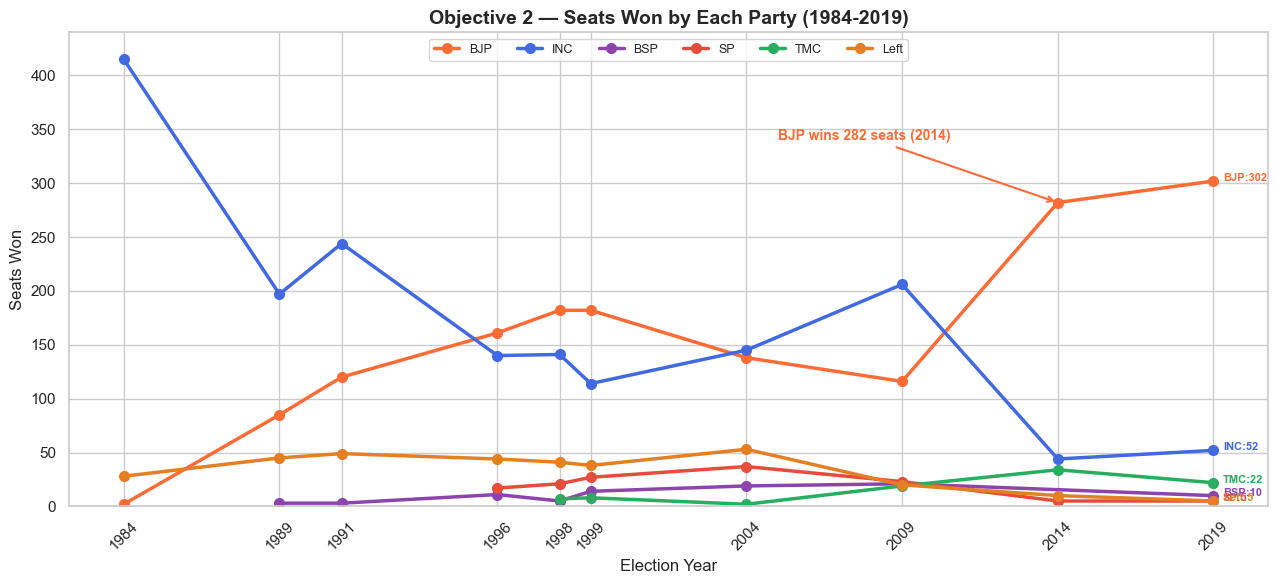

Finding: INC 414 -> 52  |  BJP 2 -> 303 — Indian politics ka sabse bada shift!


In [15]:
# Chart 2.1 — Seats Trend Line
party_list = ['BJP','INC','BSP','SP','TMC','Left']

plt.figure(figsize=(13, 6))
for party in party_list:
    d = seats[seats['Party']==party]
    if len(d) == 0: continue
    plt.plot(d['Year'], d['Seats'], marker='o', linewidth=2.5, markersize=7,
             label=party, color=COLORS.get(party,'gray'))
    last = d.iloc[-1]
    plt.text(last['Year']+0.3, last['Seats'], f"{party}:{int(last['Seats'])}",
             fontsize=8, color=COLORS.get(party,'gray'), fontweight='bold')

plt.annotate('BJP wins 282 seats (2014)', xy=(2014, 282), xytext=(2005, 340),
             arrowprops=dict(arrowstyle='->', color='#FF6B35', lw=1.5),
             color='#FF6B35', fontsize=10, fontweight='bold')
plt.title('Objective 2 — Seats Won by Each Party (1984-2019)', fontsize=14, fontweight='bold')
plt.xlabel('Election Year')
plt.ylabel('Seats Won')
plt.legend(loc='upper center', fontsize=9, ncol=6)
plt.ylim(0, 440)
plt.xticks([1984,1989,1991,1996,1998,1999,2004,2009,2014,2019], rotation=45)
plt.tight_layout()
plt.savefig('viz_2_1_seats_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: INC 414 -> 52  |  BJP 2 -> 303 — Indian politics ka sabse bada shift!")

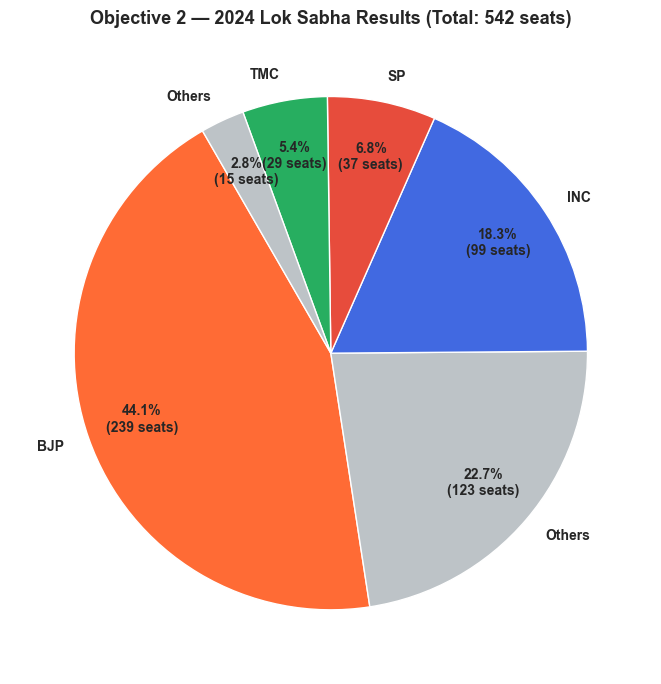

In [16]:
# Chart 2.2 — 2024 Seat Share Pie
top5 = seats_2024.head(5).copy()
others = seats_2024['Seats'].sum() - top5['Seats'].sum()
if others > 0:
    top5 = pd.concat([top5, pd.DataFrame({'Party':['Others'],'Seats':[others]})], ignore_index=True)
pie_colors = [COLORS.get(p,'#95A5A6') for p in top5['Party']]
total = top5['Seats'].sum()

plt.figure(figsize=(9, 7))
plt.pie(top5['Seats'], labels=top5['Party'], colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*total/100))} seats)',
        startangle=120, pctdistance=0.78,
        textprops={'fontsize':10,'fontweight':'bold'})
plt.title(f'Objective 2 — 2024 Lok Sabha Results (Total: {total} seats)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_2_2_2024_pie.png', dpi=120, bbox_inches='tight')
plt.show()

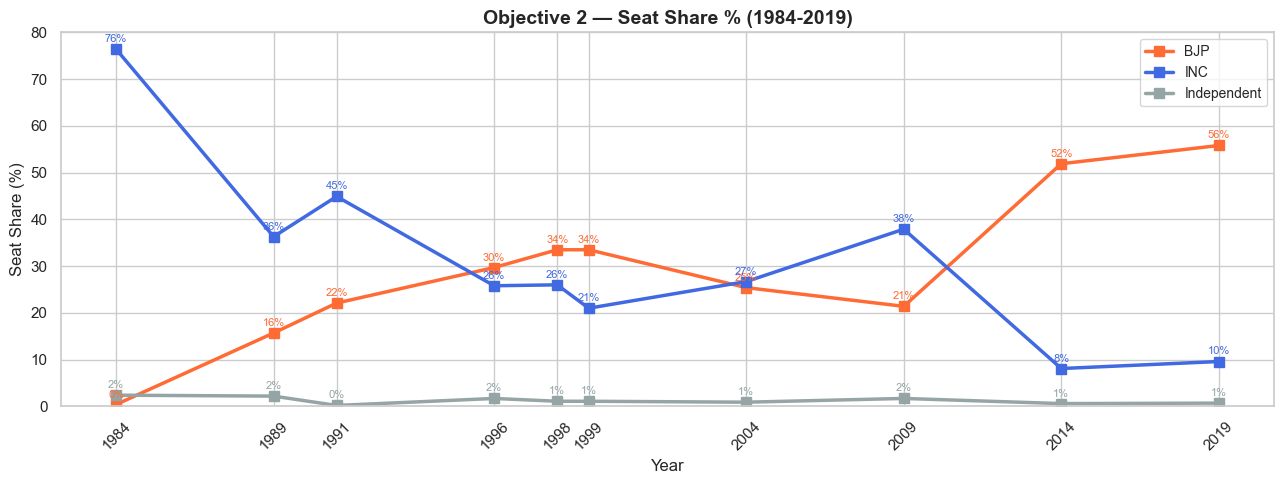

In [17]:
# Chart 2.3 — Seat Share % Trend
totals = df_modern.groupby('year').size().reset_index(name='Total').rename(columns={'year':'Year'})
sp = seats.merge(totals, on='Year')
sp['Share_Pct'] = (sp['Seats']/sp['Total']*100).round(1)

plt.figure(figsize=(13, 5))
for party in ['BJP','INC','Independent']:
    d = sp[sp['Party']==party]
    if len(d) == 0: continue
    plt.plot(d['Year'], d['Share_Pct'], marker='s', linewidth=2.5, markersize=7,
             label=party, color=COLORS.get(party,'gray'))
    for _, r in d.iterrows():
        plt.text(r['Year'], r['Share_Pct']+1.5, f"{r['Share_Pct']:.0f}%",
                 ha='center', fontsize=8, color=COLORS.get(party,'gray'))
plt.title('Objective 2 — Seat Share % (1984-2019)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Seat Share (%)')
plt.legend(fontsize=10)
plt.ylim(0, 80)
plt.xticks([1984,1989,1991,1996,1998,1999,2004,2009,2014,2019], rotation=45)
plt.tight_layout()
plt.savefig('viz_2_3_seat_share.png', dpi=120, bbox_inches='tight')
plt.show()

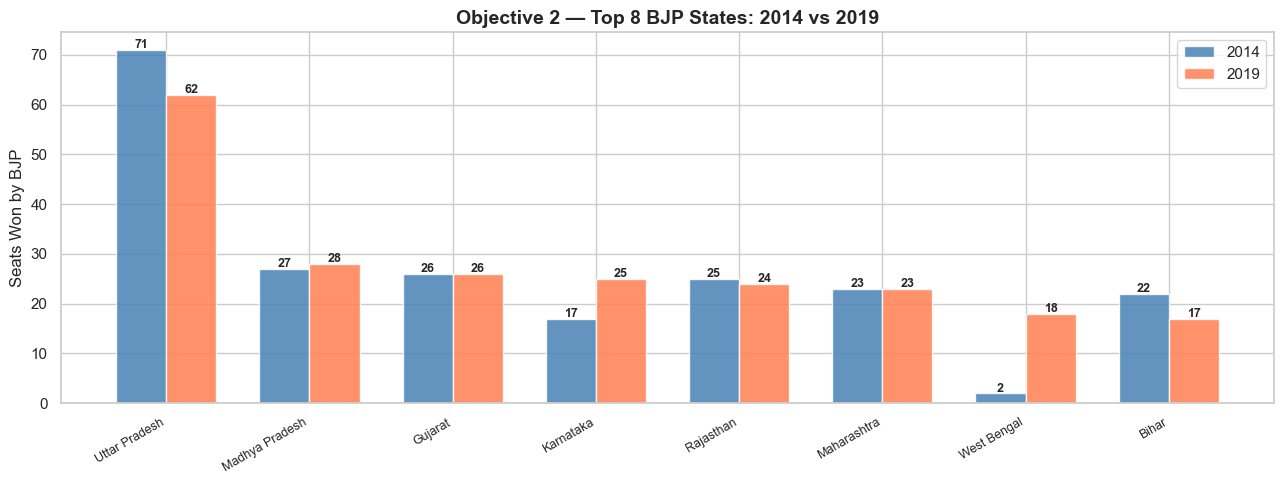

Finding: UP akele BJP ko 60-70+ seats deta hai — UP jeetna mandatory hai!


In [18]:
# Chart 2.4 — Top 8 BJP States 2014 vs 2019
bjp = df_modern[df_modern['party_group']=='BJP']
s14 = bjp[bjp['year']==2014].groupby('state').size().reset_index(name='Seats_2014')
s19 = bjp[bjp['year']==2019].groupby('state').size().reset_index(name='Seats_2019')
top8 = s19.nlargest(8,'Seats_2019').merge(s14, on='state', how='left').fillna(0)

x = np.arange(len(top8))
w = 0.35

plt.figure(figsize=(13, 5))
b1 = plt.bar(x-w/2, top8['Seats_2014'], w, label='2014', color='steelblue', alpha=0.85)
b2 = plt.bar(x+w/2, top8['Seats_2019'], w, label='2019', color='coral', alpha=0.85)
for bars in [b1, b2]:
    for b in bars:
        if b.get_height() > 0:
            plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                     int(b.get_height()), ha='center', fontsize=9, fontweight='bold')
plt.xticks(x, top8['state'], rotation=30, ha='right', fontsize=9)
plt.ylabel('Seats Won by BJP')
plt.title('Objective 2 — Top 8 BJP States: 2014 vs 2019', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('viz_2_4_bjp_states.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: UP akele BJP ko 60-70+ seats deta hai — UP jeetna mandatory hai!")

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #f39c12;margin-top:10px;">
<h2 style="color:#f39c12;">Objective 3: Candidate Profile Analysis</h2>
<p style="color:#ccc;"><b>Goal:</b> Do criminal candidates win more? Does money & age & incumbency help in winning?</p></div>

In [19]:
# Basic stats
print("Total candidates   :", len(df_aff))
print("Winners            :", df_aff['Winner'].sum())
print("With criminal case :", df_aff['HasCriminal'].sum())
print("Crorepati          :", df_aff['Crorepati'].sum())
print("Women candidates   :", df_aff['Women'].sum())
print()
print(df_aff[['CriminalCases','TotalAssets_Cr','Age','Winner']].describe())

Total candidates   : 27447
Winners            : 1959
With criminal case : 4495
Crorepati          : 6147
Women candidates   : 2111

       CriminalCases  TotalAssets_Cr           Age        Winner
count   27447.000000    27447.000000  27447.000000  27447.000000
mean        0.484315        3.304687     46.464576      0.071374
std         4.188845       55.268237     12.607853      0.257453
min         0.000000        0.000000      0.000000      0.000000
25%         0.000000        0.027245     37.000000      0.000000
50%         0.000000        0.168318     46.000000      0.000000
75%         0.000000        0.808831     55.000000      0.000000
max       382.000000     7710.295722     94.000000      1.000000


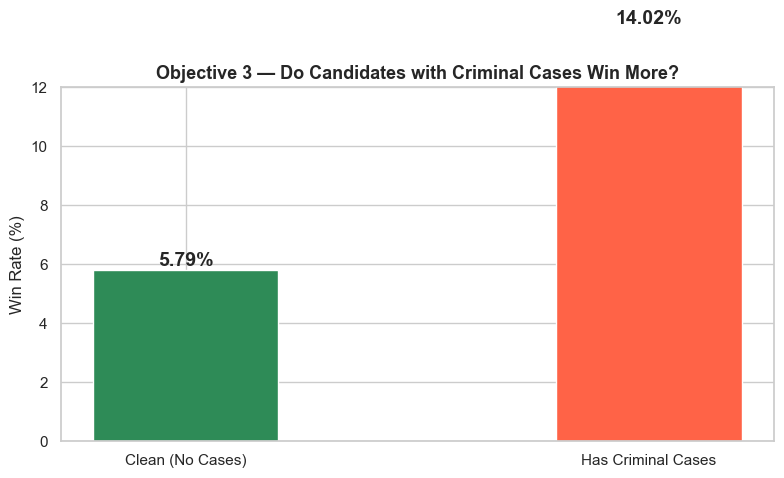

SHOCKING: Criminal records wale candidates ki win rate ZYADA hai!


In [20]:
# Chart 3.1 — Win Rate: Criminal vs Clean
win_crim = df_aff.groupby('HasCriminal')['Winner'].mean().mul(100).reset_index()
win_crim['Label']    = win_crim['HasCriminal'].map({0:'Clean (No Cases)', 1:'Has Criminal Cases'})
win_crim['Win_Rate'] = win_crim['Winner']

plt.figure(figsize=(8, 5))
bars = plt.bar(win_crim['Label'], win_crim['Win_Rate'],
               color=['seagreen','tomato'], width=0.4, edgecolor='white')
for b, v in zip(bars, win_crim['Win_Rate']):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.15,
             f'{v:.2f}%', ha='center', fontsize=14, fontweight='bold')
plt.title('Objective 3 — Do Candidates with Criminal Cases Win More?',
          fontsize=13, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 12)
plt.tight_layout()
plt.savefig('viz_3_1_criminal_winrate.png', dpi=120, bbox_inches='tight')
plt.show()
print('SHOCKING: Criminal records wale candidates ki win rate ZYADA hai!')


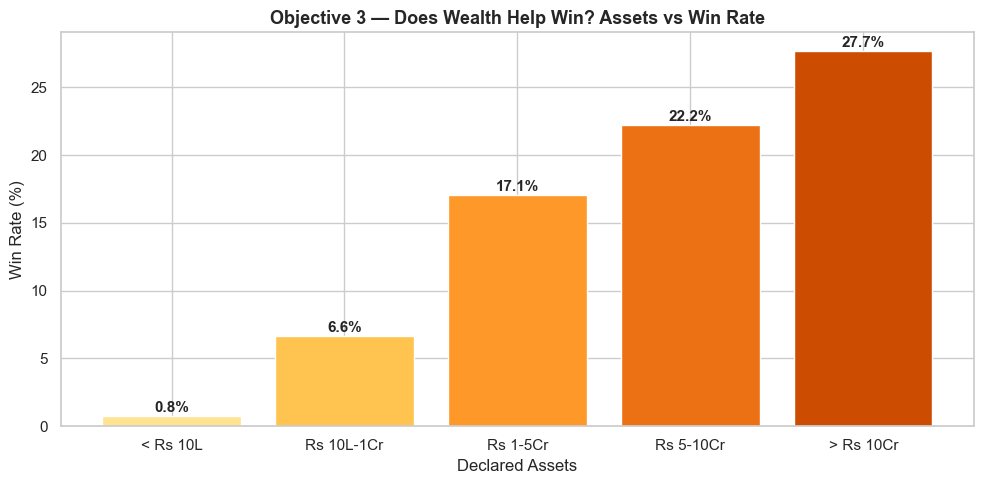

Finding: Jitna zyada paisa, utni zyada win rate!


In [21]:
# Chart 3.2 — Wealth vs Win Rate
df_aff['Wealth'] = pd.cut(df_aff['TotalAssets_Cr'],
    bins=[-0.1, 0.1, 1, 5, 10, 1e6],
    labels=['< Rs 10L','Rs 10L-1Cr','Rs 1-5Cr','Rs 5-10Cr','> Rs 10Cr'])
wr_wealth = df_aff.groupby('Wealth', observed=True)['Winner'].mean().mul(100).reset_index()
wr_wealth.columns = ['Wealth','Win_Rate']

plt.figure(figsize=(10, 5))
bars = plt.bar(wr_wealth['Wealth'].astype(str), wr_wealth['Win_Rate'],
               color=['#FEE391','#FEC44F','#FE9929','#EC7014','#CC4C02'],
               edgecolor='white')
for b, v in zip(bars, wr_wealth['Win_Rate']):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Objective 3 — Does Wealth Help Win? Assets vs Win Rate',
          fontsize=13, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.xlabel('Declared Assets')
plt.tight_layout()
plt.savefig('viz_3_2_wealth_winrate.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Jitna zyada paisa, utni zyada win rate!")

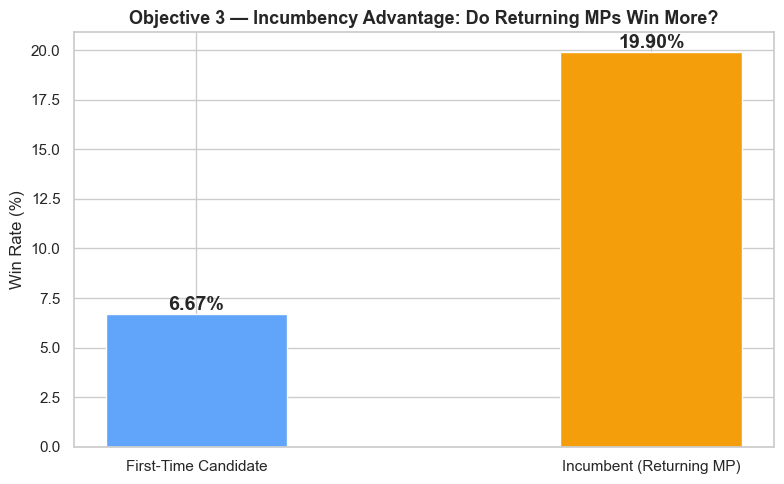

Finding: Returning MPs ki win rate first-timers se zyada — naam recognition matters!


In [22]:
# Chart 3.3 — Incumbency Advantage
wr_inc = df_aff.groupby('ReturningCandidate')['Winner'].mean().mul(100).reset_index()
wr_inc['Label'] = wr_inc['ReturningCandidate'].map({0:'First-Time Candidate',1:'Incumbent (Returning MP)'})

plt.figure(figsize=(8, 5))
bars = plt.bar(wr_inc['Label'], wr_inc['Winner'],
               color=['#60a5fa','#f59e0b'], width=0.4, edgecolor='white')
for b, v in zip(bars, wr_inc['Winner']):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
             f'{v:.2f}%', ha='center', fontsize=14, fontweight='bold')
plt.title('Objective 3 — Incumbency Advantage: Do Returning MPs Win More?',
          fontsize=13, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.savefig('viz_3_3_incumbency.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Returning MPs ki win rate first-timers se zyada — naam recognition matters!")

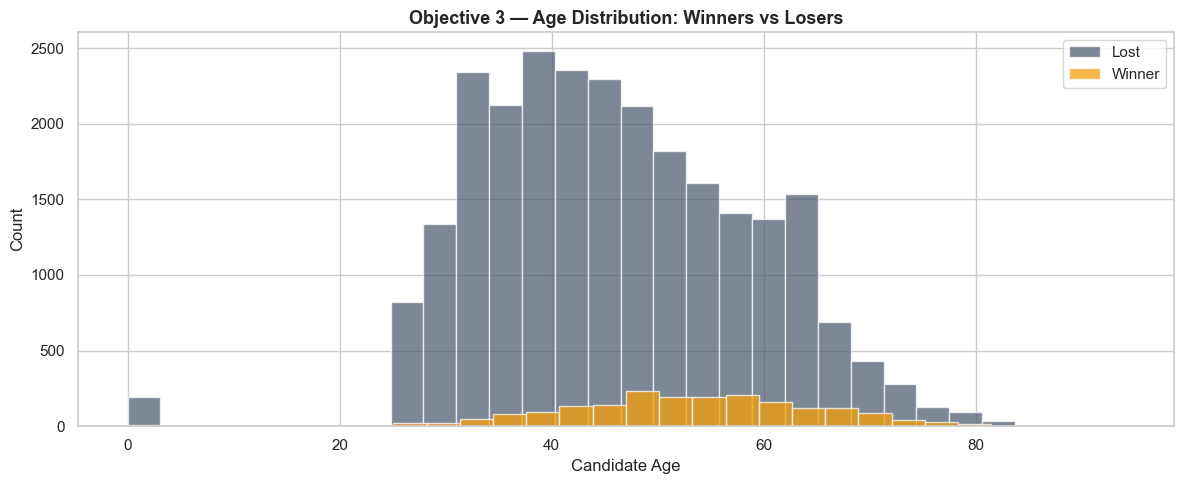

In [23]:
# Chart 3.4 — Age Distribution Winners vs Losers
df_aff['Result'] = df_aff['Winner'].map({1:'Winner', 0:'Lost'})

plt.figure(figsize=(12, 5))
plt.hist(df_aff[df_aff['Result']=='Lost']['Age'].dropna(), bins=30,
         alpha=0.7, color='#475569', label='Lost', edgecolor='white')
plt.hist(df_aff[df_aff['Result']=='Winner']['Age'].dropna(), bins=30,
         alpha=0.75, color='#f59e0b', label='Winner', edgecolor='white')
plt.title('Objective 3 — Age Distribution: Winners vs Losers',
          fontsize=13, fontweight='bold')
plt.xlabel('Candidate Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('viz_3_4_age_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #1abc9c;margin-top:10px;">
<h2 style="color:#1abc9c;">Objective 4: Winning Margin & Swing Seats</h2>
<p style="color:#ccc;"><b>Goal:</b> Which seats are safe and which are swing? Swing seats decide who becomes PM.</p></div>

In [24]:
# Classify seats
def classify_seat(m):
    if pd.isna(m):  return 'Unknown'
    if m < 5:       return 'Swing (< 5%)'
    if m < 15:      return 'Competitive (5-15%)'
    return 'Safe (> 15%)'

df_main['seat_type'] = df_main['margin_pct'].apply(classify_seat)
print("All years:")
print(df_main['seat_type'].value_counts())
print("\n2019 only:")
print(df_main[df_main['year']==2019]['seat_type'].value_counts())

All years:
seat_type
Safe (> 15%)           3309
Competitive (5-15%)    2855
Swing (< 5%)           1829
Unknown                  53
Name: count, dtype: int64

2019 only:
seat_type
Safe (> 15%)           274
Competitive (5-15%)    172
Swing (< 5%)            95
Name: count, dtype: int64


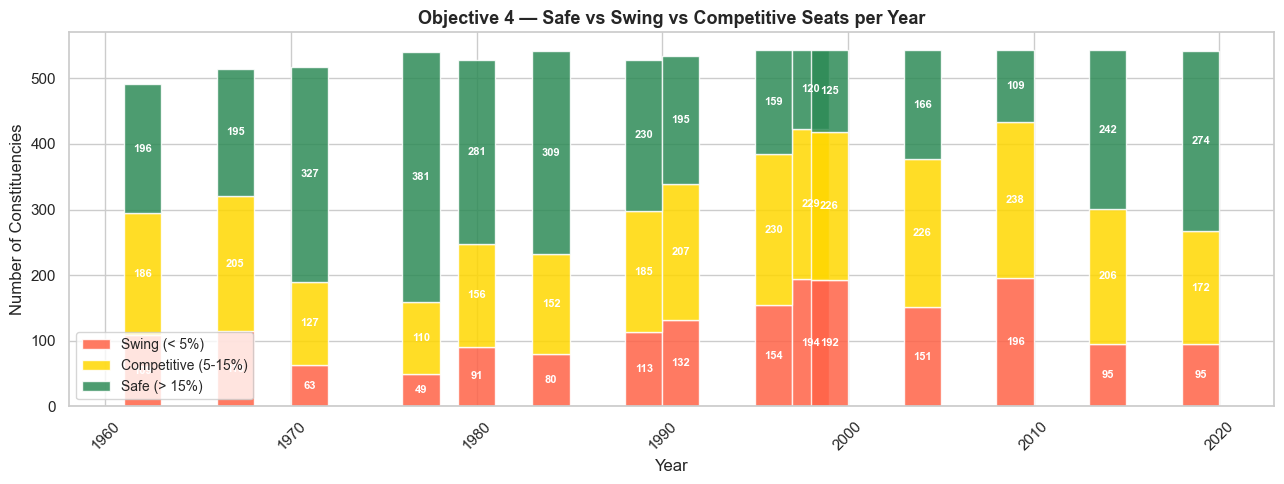

In [25]:
# Chart 4.1 — Seat Types per Year (Stacked Bar)
seat_yr = df_main.groupby(['year','seat_type']).size().reset_index(name='Count')
pivot   = seat_yr.pivot(index='year', columns='seat_type', values='Count').fillna(0)

colors_seat = {'Swing (< 5%)':'tomato','Competitive (5-15%)':'gold','Safe (> 15%)':'seagreen'}
bottom = np.zeros(len(pivot))

plt.figure(figsize=(13, 5))
for stype, color in colors_seat.items():
    if stype not in pivot.columns: continue
    vals = pivot[stype].values
    plt.bar(pivot.index, vals, bottom=bottom, label=stype,
            color=color, alpha=0.85, edgecolor='white', width=2)
    for i, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 20:
            plt.text(pivot.index[i], bot+val/2, int(val),
                     ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    bottom += vals

plt.title('Objective 4 — Safe vs Swing vs Competitive Seats per Year',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Constituencies')
plt.legend(loc='lower left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_4_1_seat_types.png', dpi=120, bbox_inches='tight')
plt.show()

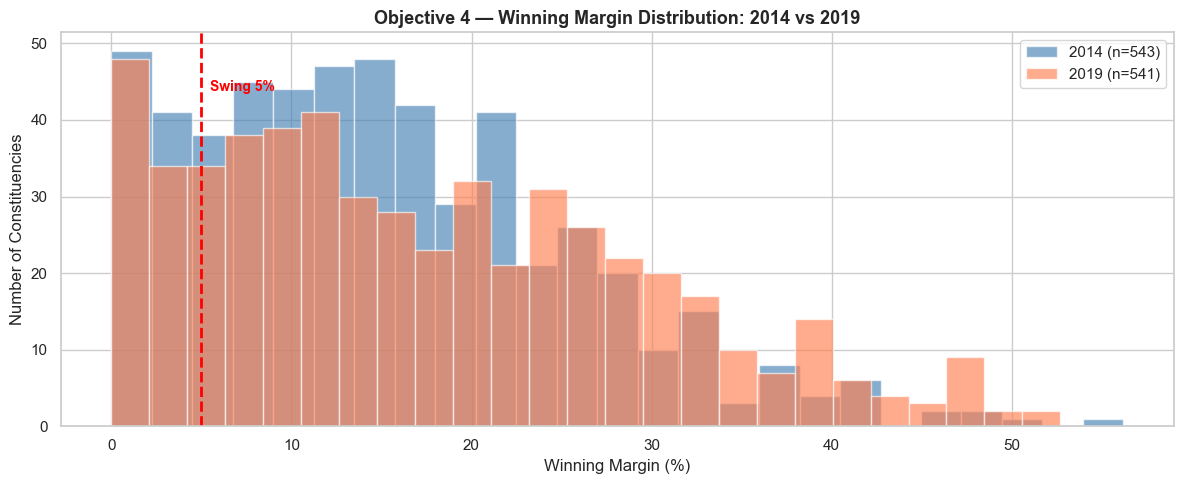

In [26]:
# Chart 4.2 — Margin Distribution 2014 vs 2019
m2014 = df_main[df_main['year']==2014]['margin_pct'].dropna()
m2019 = df_main[df_main['year']==2019]['margin_pct'].dropna()

plt.figure(figsize=(12, 5))
plt.hist(m2014, bins=25, alpha=0.65, color='steelblue',
         label=f'2014 (n={len(m2014)})', edgecolor='white')
plt.hist(m2019, bins=25, alpha=0.65, color='coral',
         label=f'2019 (n={len(m2019)})', edgecolor='white')
plt.axvline(x=5, color='red', linestyle='--', linewidth=2)
plt.text(5.5, plt.ylim()[1]*0.85, 'Swing 5%', color='red', fontsize=10, fontweight='bold')
plt.title('Objective 4 — Winning Margin Distribution: 2014 vs 2019',
          fontsize=13, fontweight='bold')
plt.xlabel('Winning Margin (%)')
plt.ylabel('Number of Constituencies')
plt.legend()
plt.tight_layout()
plt.savefig('viz_4_2_margin_hist.png', dpi=120, bbox_inches='tight')
plt.show()

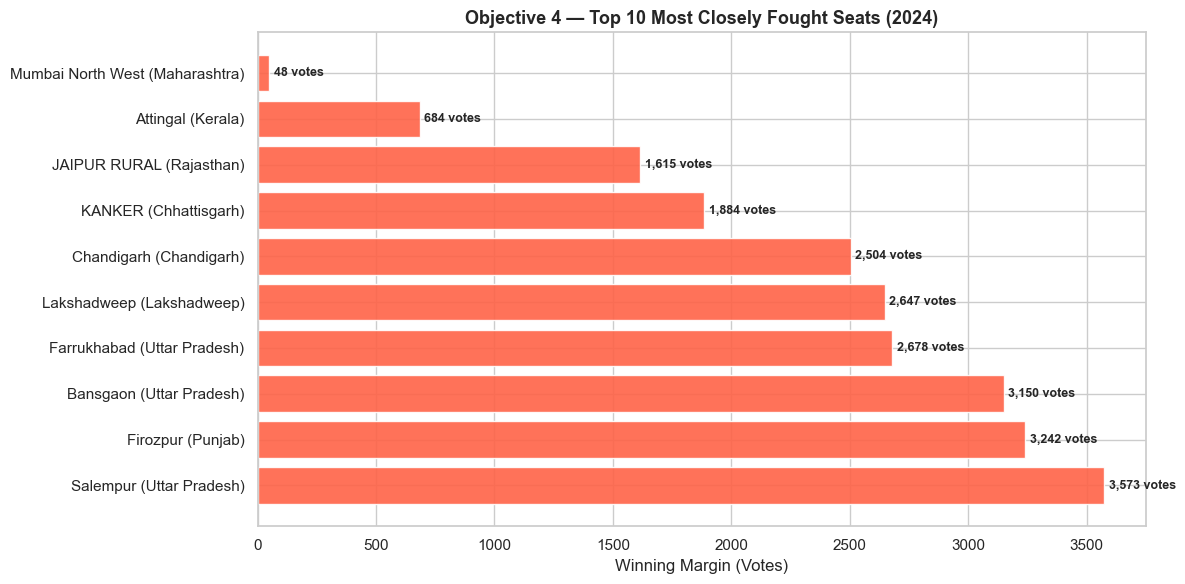

Finding: Kai seats 500 se kam votes se decide hui — har vote matters!


In [27]:
# Chart 4.3 — Top 10 Tightest Seats 2024
df_m24['Margin'] = pd.to_numeric(df_m24['Margin'], errors='coerce')
tight = df_m24.dropna(subset=['Margin']).nsmallest(10,'Margin').copy()
tight['Label'] = tight['PC Name'] + ' (' + tight['State'] + ')'

plt.figure(figsize=(12, 6))
bars = plt.barh(tight['Label'], tight['Margin'], color='tomato', edgecolor='white', alpha=0.9)
for b in bars:
    plt.text(b.get_width()+20, b.get_y()+b.get_height()/2,
             f'{int(b.get_width()):,} votes', va='center', fontsize=9, fontweight='bold')
plt.title('Objective 4 — Top 10 Most Closely Fought Seats (2024)',
          fontsize=13, fontweight='bold')
plt.xlabel('Winning Margin (Votes)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('viz_4_3_tight_seats.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Kai seats 500 se kam votes se decide hui — har vote matters!")

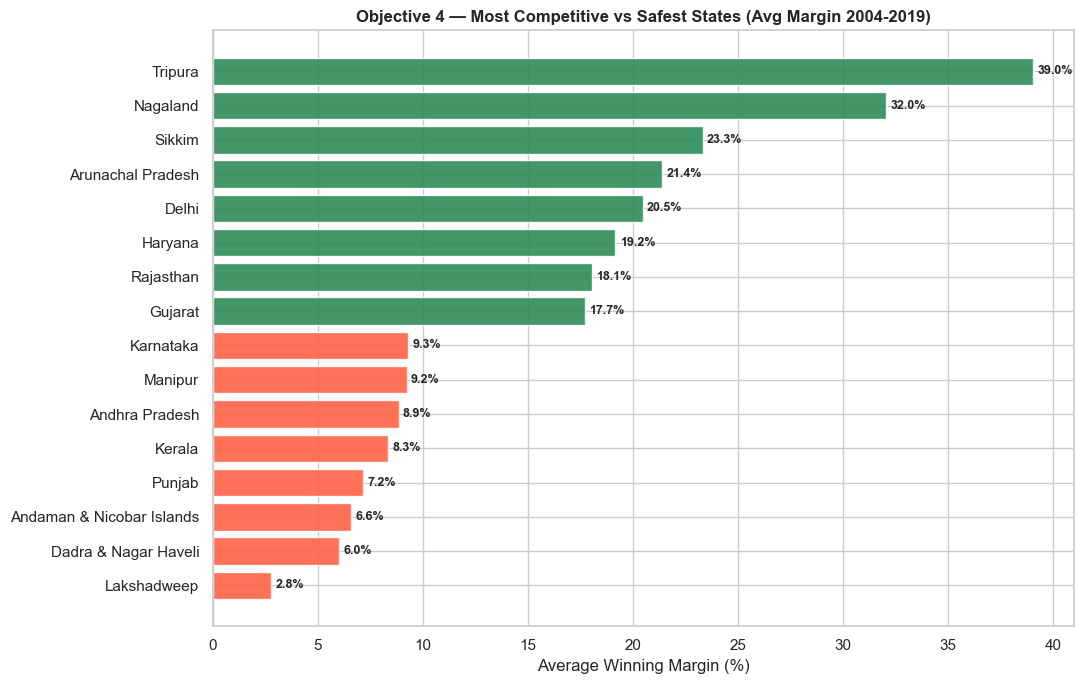

In [28]:
# Chart 4.4 — State-wise Average Margin
state_margin = df_main[df_main['year']>=2004].groupby('state')['margin_pct'].mean().reset_index()
state_margin.columns = ['State','Avg_Margin']
state_margin = state_margin.dropna().sort_values('Avg_Margin')
show_df = pd.concat([state_margin.head(8), state_margin.tail(8)]).drop_duplicates()
colors_m = ['tomato' if v < 12 else 'seagreen' for v in show_df['Avg_Margin']]

plt.figure(figsize=(11, 7))
bars = plt.barh(show_df['State'], show_df['Avg_Margin'], color=colors_m, edgecolor='white', alpha=0.9)
for b in bars:
    plt.text(b.get_width()+0.2, b.get_y()+b.get_height()/2,
             f'{b.get_width():.1f}%', va='center', fontsize=9, fontweight='bold')
plt.title('Objective 4 — Most Competitive vs Safest States (Avg Margin 2004-2019)',
          fontsize=12, fontweight='bold')
plt.xlabel('Average Winning Margin (%)')
plt.tight_layout()
plt.savefig('viz_4_4_state_margins.png', dpi=120, bbox_inches='tight')
plt.show()

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #9b59b6;margin-top:10px;">
<h2 style="color:#9b59b6;">Objective 5: Machine Learning — Predicting Winners</h2>
<p style="color:#ccc;"><b>Goal:</b> Can a computer learn from 16 years of data and predict who will win? Feature importance = what REALLY decides elections.</p></div>

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

FEATURES = ['HasCriminal','CriminalCases','TotalAssets_Cr','Age','Crorepati','ReturningCandidate']

df_ml = df_aff[FEATURES+['Winner']].dropna().copy()
df_ml['Winner'] = df_ml['Winner'].astype(int)

X = df_ml[FEATURES]
y = df_ml['Winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")
print(f"Winner distribution: {dict(y.value_counts())}")

Training samples: 21,957
Testing samples : 5,490
Winner distribution: {0: np.int64(25488), 1: np.int64(1959)}


In [30]:
# Train Model 1 — Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_s, y_train)
pred_lr = model_lr.predict(X_test_s)
acc_lr = accuracy_score(y_test, pred_lr) * 100
print("Logistic Regression Accuracy:", round(acc_lr, 2), "%")

# Train Model 2 — Decision Tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt) * 100
print("Decision Tree Accuracy:", round(acc_dt, 2), "%")

# Train Model 3 — Random Forest
model_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf) * 100
print("Random Forest Accuracy:", round(acc_rf, 2), "%")

# Train Model 4 — Gradient Boosting
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
pred_gb = model_gb.predict(X_test)
acc_gb = accuracy_score(y_test, pred_gb) * 100
print("Gradient Boosting Accuracy:", round(acc_gb, 2), "%")

# Compare all models
df_res = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','Gradient Boosting'],
    'Accuracy': [round(acc_lr,2), round(acc_dt,2), round(acc_rf,2), round(acc_gb,2)]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

best_model_name = df_res.iloc[0]['Model']
predictions = {
    'Logistic Regression': pred_lr, 'Decision Tree': pred_dt,
    'Random Forest': pred_rf, 'Gradient Boosting': pred_gb
}
print("\nBest Model:", best_model_name)
print(df_res.to_string(index=False))

Logistic Regression Accuracy: 92.84 %
Decision Tree Accuracy: 92.84 %
Random Forest Accuracy: 92.91 %
Gradient Boosting Accuracy: 92.68 %

Best Model: Random Forest
              Model  Accuracy
      Random Forest     92.91
Logistic Regression     92.84
      Decision Tree     92.84
  Gradient Boosting     92.68


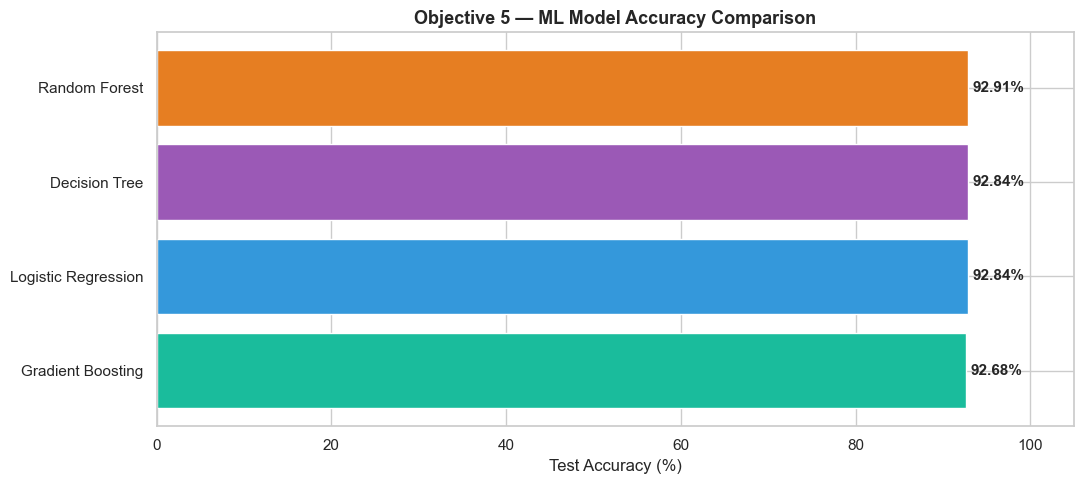

In [31]:
# Chart 5.1 — Model Accuracy Bar
df_res_plot = df_res.sort_values('Accuracy')
colors_ml = ['#1abc9c','#3498db','#9b59b6','#e67e22']

plt.figure(figsize=(11, 5))
bars = plt.barh(df_res_plot['Model'], df_res_plot['Accuracy'],
                color=colors_ml, edgecolor='white')
for b in bars:
    plt.text(b.get_width()+0.5, b.get_y()+b.get_height()/2,
             f'{b.get_width():.2f}%', va='center', fontsize=11, fontweight='bold')
plt.title('Objective 5 — ML Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Test Accuracy (%)')
plt.xlim(0, 105)
plt.tight_layout()
plt.savefig('viz_5_1_model_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

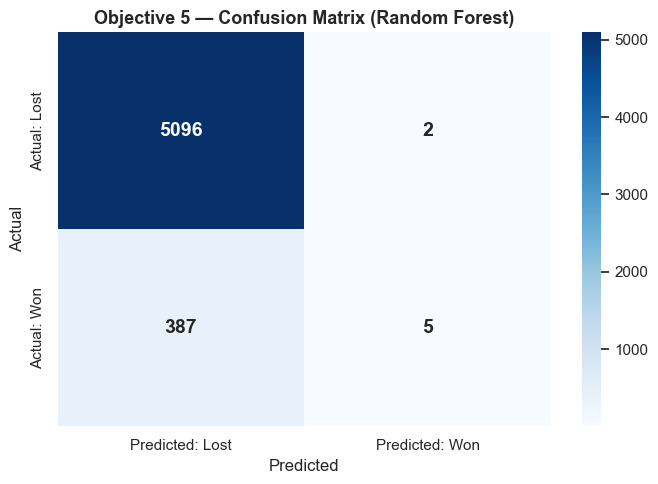

Classification Report:
              precision    recall  f1-score   support

        Lost       0.93      1.00      0.96      5098
         Won       0.71      0.01      0.03       392

    accuracy                           0.93      5490
   macro avg       0.82      0.51      0.49      5490
weighted avg       0.91      0.93      0.90      5490



In [32]:
# Chart 5.2 — Confusion Matrix (Best Model)
best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Lost','Predicted: Won'],
            yticklabels=['Actual: Lost','Actual: Won'],
            annot_kws={'size':14,'weight':'bold'})
plt.title(f'Objective 5 — Confusion Matrix ({best_model_name})',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('viz_5_2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Classification Report:")
print(classification_report(y_test, best_pred, target_names=['Lost','Won'], zero_division=0))

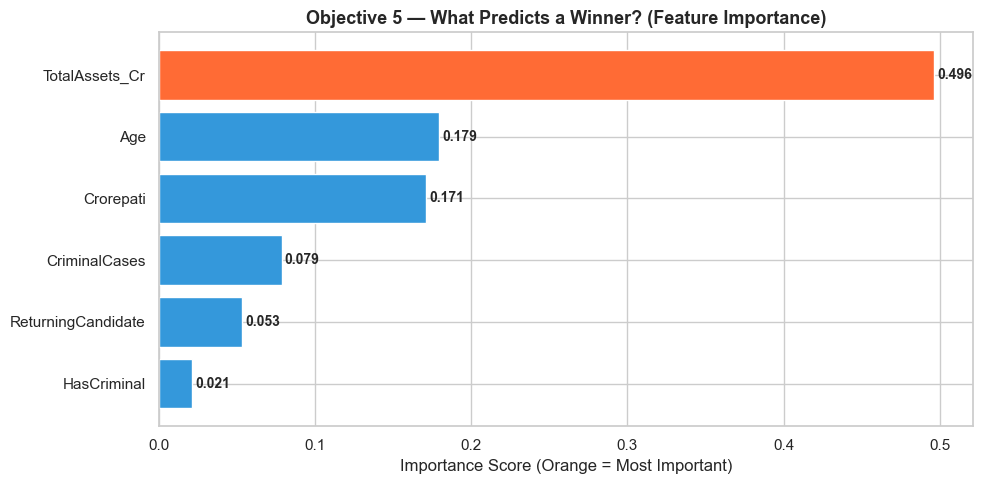

Finding: Total Assets sabse bada predictor — paisa sabse strong factor hai!


In [33]:
# Chart 5.3 — Feature Importance (Random Forest)
feat_imp = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance')
colors_f = ['#FF6B35' if v==feat_imp['Importance'].max() else '#3498DB' for v in feat_imp['Importance']]

plt.figure(figsize=(10, 5))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=colors_f, edgecolor='white')
for b in bars:
    plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2,
             f'{b.get_width():.3f}', va='center', fontsize=10, fontweight='bold')
plt.title('Objective 5 — What Predicts a Winner? (Feature Importance)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (Orange = Most Important)')
plt.tight_layout()
plt.savefig('viz_5_3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Total Assets sabse bada predictor — paisa sabse strong factor hai!")

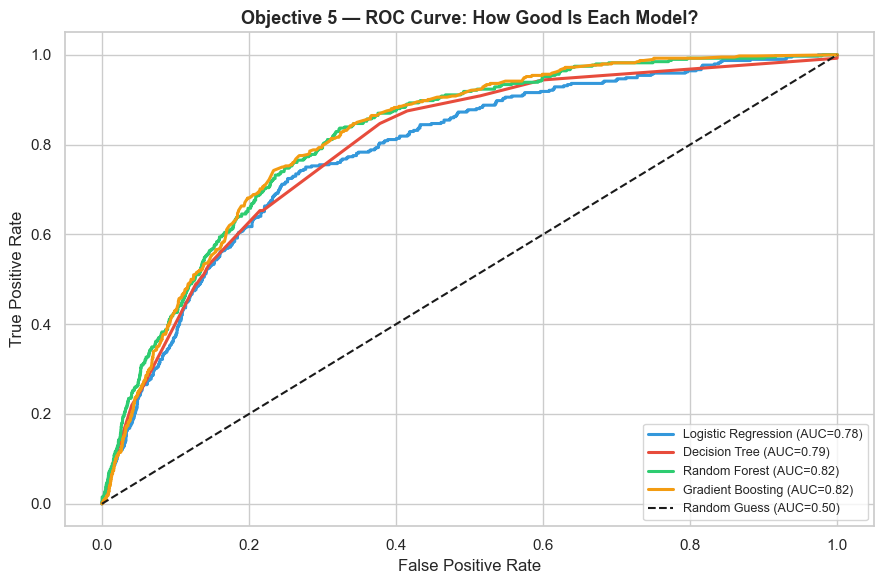

Finding: AUC > 0.5 matlab model random guess se behtar hai!


In [34]:
# Chart 5.4 — ROC Curve (All Models)
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))
roc_colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12']
model_roc_pairs = [
    ('Logistic Regression', model_lr, True),
    ('Decision Tree',       model_dt, False),
    ('Random Forest',       model_rf, False),
    ('Gradient Boosting',   model_gb, False)
]
for (name, model, scaled), color in zip(model_roc_pairs, roc_colors):
    Xte = X_test_s if scaled else X_test
    y_prob = model.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random Guess (AUC=0.50)')
plt.title('Objective 5 — ROC Curve: How Good Is Each Model?', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('viz_5_4_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: AUC > 0.5 matlab model random guess se behtar hai!")

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #e67e22;margin-top:10px;">
<h2 style="color:#e67e22;">Objective 6: Delimitation + Population Prediction + Women Seats After Redistribution</h2>
<p style="color:#ccc;"><b>Goal:</b> After 2027 Census, seats redistribute by population. North gains, South loses. Then 33% of new seats go to women — how many women seats does each state get?</p></div>

In [35]:
# Real census data load — filter only States (not India/Union Territory)
df_pop = df_census[df_census['Category']=='State'].copy()
df_pop.columns = ['Category','State','Pop_2011','Growth_Rate','Density']
df_pop['Pop_2011']    = pd.to_numeric(df_pop['Pop_2011'], errors='coerce')
df_pop['Growth_Rate'] = pd.to_numeric(df_pop['Growth_Rate'], errors='coerce')
df_pop = df_pop.dropna(subset=['Pop_2011','Growth_Rate'])

# Predict 2027 population
# Growth_Rate is decadal % (e.g. 17.64 means 17.64% growth in 10 years)
# Dampened by 15% to account for slowing growth
# For 16 years (2011 to 2027): use (1 + dampened_rate/100)^(16/10)
df_pop['Dampened_Rate'] = df_pop['Growth_Rate'] * 0.85
df_pop['Pop_2027']      = df_pop['Pop_2011'] * ((1 + df_pop['Dampened_Rate']/100) ** (16/10))
df_pop['Pop_2011_Cr']   = df_pop['Pop_2011'] / 1e7
df_pop['Pop_2027_Cr']   = df_pop['Pop_2027'] / 1e7

# Current Lok Sabha seats
seats_current = {
    'Uttar Pradesh':80,'Maharashtra':48,'Bihar':40,'West Bengal':42,
    'Madhya Pradesh':29,'Rajasthan':25,'Tamil Nadu':39,'Karnataka':28,
    'Gujarat':26,'Andhra Pradesh':25,'Odisha':21,'Telangana':17,
    'Kerala':20,'Jharkhand':14,'Assam':14,'Punjab':13,
    'Chhattisgarh':11,'Haryana':10,'Uttarakhand':5,'Himachal Pradesh':4,
    'Tripura':2,'Meghalaya':2,'Manipur':2,'Nagaland':1,'Goa':2,
    'Arunachal Pradesh':2,'Mizoram':1,'Sikkim':1
}
df_pop['Current_Seats'] = df_pop['State'].map(seats_current)
df_pop = df_pop.dropna(subset=['Current_Seats'])
df_pop['Current_Seats'] = df_pop['Current_Seats'].astype(int)

# Scenario A: 543 seats redistributed by 2027 population
total_pop = df_pop['Pop_2027'].sum()
df_pop['New_Seats'] = ((df_pop['Pop_2027']/total_pop)*543).round(0).astype(int)
df_pop['Change']    = df_pop['New_Seats'] - df_pop['Current_Seats']

# Region tagging
north = ['Uttar Pradesh','Bihar','Rajasthan','Haryana','Punjab','Uttarakhand',
         'Himachal Pradesh','Madhya Pradesh','Chhattisgarh','Jharkhand']
south = ['Tamil Nadu','Kerala','Karnataka','Andhra Pradesh','Telangana']
df_pop['Region'] = df_pop['State'].apply(
    lambda s: 'North' if s in north else ('South' if s in south else 'Other'))

# Women seats after delimitation (33% rule)
df_pop['Current_Women_Seats'] = (df_pop['Current_Seats'] * 0.33).round(0).astype(int)
df_pop['New_Women_Seats']     = (df_pop['New_Seats'] * 0.33).round(0).astype(int)
df_pop['Women_Seats_Change']  = df_pop['New_Women_Seats'] - df_pop['Current_Women_Seats']

print('Seat changes after delimitation:')
print(df_pop[['State','Current_Seats','New_Seats','Change','New_Women_Seats']]
      .sort_values('Change', ascending=False).to_string(index=False))


Seat changes after delimitation:
            State  Current_Seats  New_Seats  Change  New_Women_Seats
    Uttar Pradesh             80         95      15               31
            Bihar             40         52      12               17
        Rajasthan             25         33       8               11
   Madhya Pradesh             29         34       5               11
      Maharashtra             48         51       3               17
        Jharkhand             14         16       2                5
          Gujarat             26         28       2                9
          Haryana             10         12       2                4
     Chhattisgarh             11         12       1                4
            Assam             14         14       0                5
         Nagaland              1          1       0                0
          Mizoram              1          1       0                0
          Tripura              2          2       0                1
 

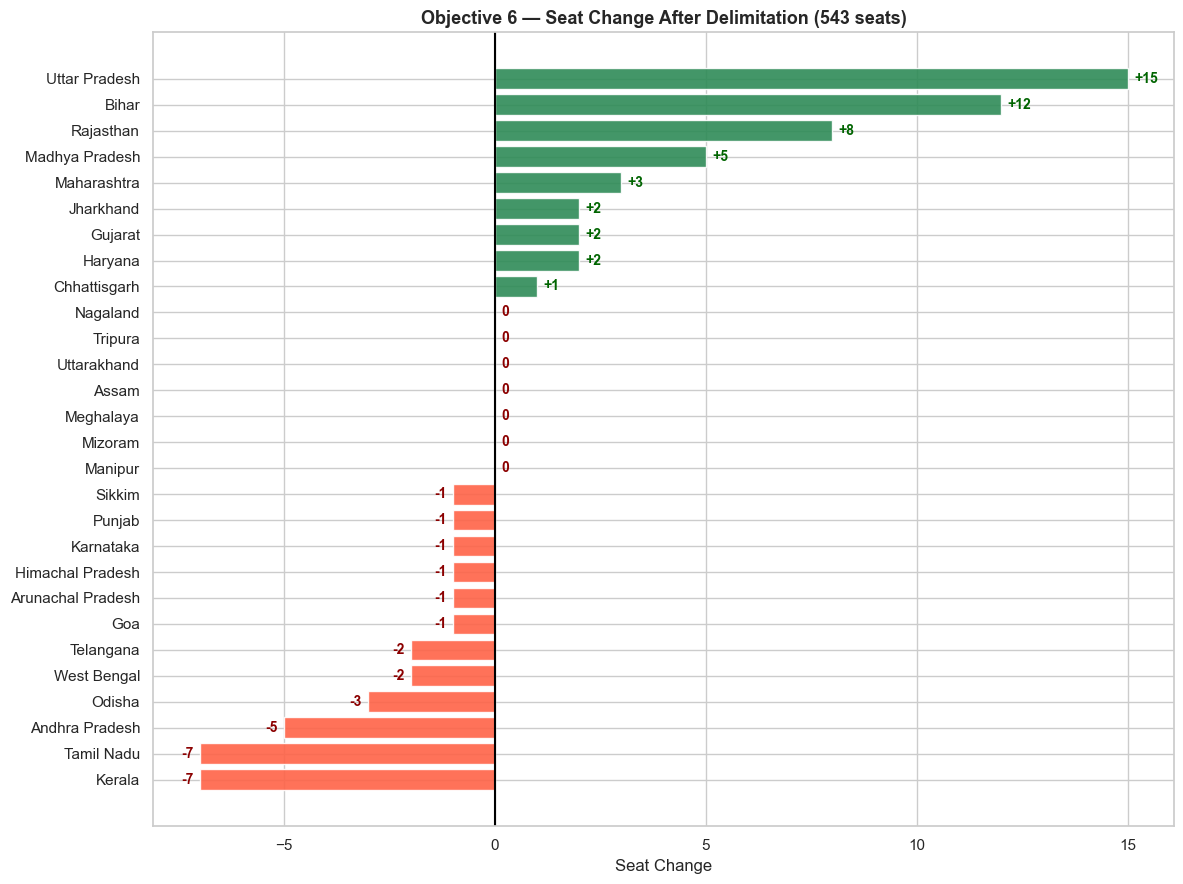

Finding: UP/Bihar bade gainer, TN/Kerala lose karenge — population control ka nuksaan!


In [36]:
# Chart 6.1 — Post-Delimitation Seat Change (All States)
df_sorted = df_pop.sort_values('Change')
colors_d  = ['seagreen' if v > 0 else 'tomato' for v in df_sorted['Change']]

plt.figure(figsize=(12, 9))
bars = plt.barh(df_sorted['State'], df_sorted['Change'],
                color=colors_d, edgecolor='white', alpha=0.9)
for b, v in zip(bars, df_sorted['Change']):
    label = f'+{int(v)}' if v > 0 else str(int(v))
    xpos  = v+0.15 if v >= 0 else v-0.15
    ha    = 'left' if v >= 0 else 'right'
    plt.text(xpos, b.get_y()+b.get_height()/2, label,
             va='center', ha=ha, fontsize=10, fontweight='bold',
             color='darkgreen' if v > 0 else 'darkred')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.title('Objective 6 — Seat Change After Delimitation (543 seats)', fontsize=13, fontweight='bold')
plt.xlabel('Seat Change')
plt.tight_layout()
plt.savefig('viz_6_1_seat_change.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: UP/Bihar bade gainer, TN/Kerala lose karenge — population control ka nuksaan!")

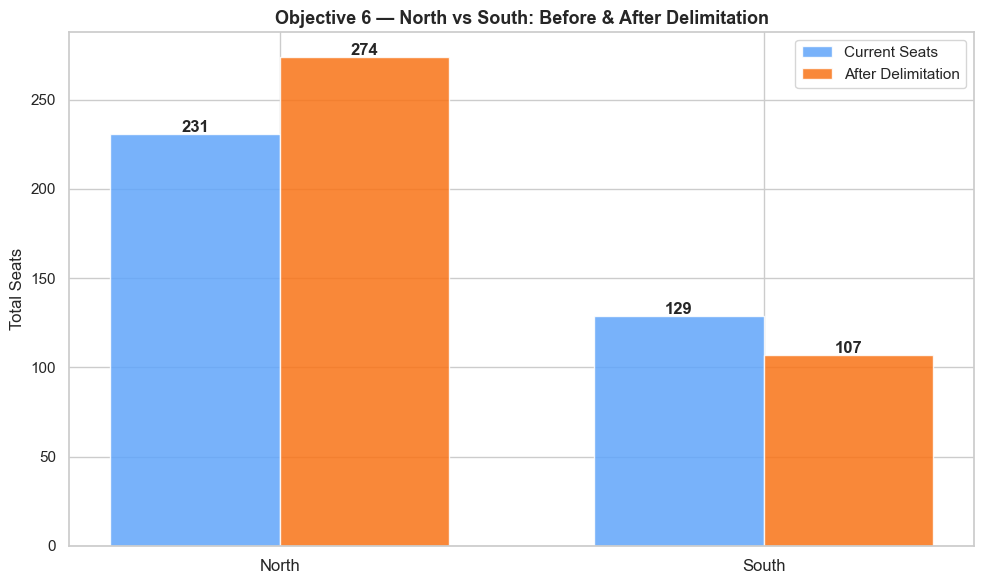

Finding: North ko power milega, South lose karega — yahi South ka protest ka kaaran hai!


In [37]:
# Chart 6.2 — North vs South Before & After
region_cmp = df_pop[df_pop['Region'].isin(['North','South'])].groupby('Region').agg(
    Current=('Current_Seats','sum'), New=('New_Seats','sum')).reset_index()

x = np.arange(len(region_cmp))
w = 0.35

plt.figure(figsize=(10, 6))
b1 = plt.bar(x-w/2, region_cmp['Current'], w, label='Current Seats',
             color='#60a5fa', alpha=0.85)
b2 = plt.bar(x+w/2, region_cmp['New'], w, label='After Delimitation',
             color='#f97316', alpha=0.85)
for bars in [b1, b2]:
    for b in bars:
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 int(b.get_height()), ha='center', fontsize=12, fontweight='bold')
plt.xticks(x, region_cmp['Region'], fontsize=12)
plt.ylabel('Total Seats')
plt.title('Objective 6 — North vs South: Before & After Delimitation',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('viz_6_2_north_south.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: North ko power milega, South lose karega — yahi South ka protest ka kaaran hai!")

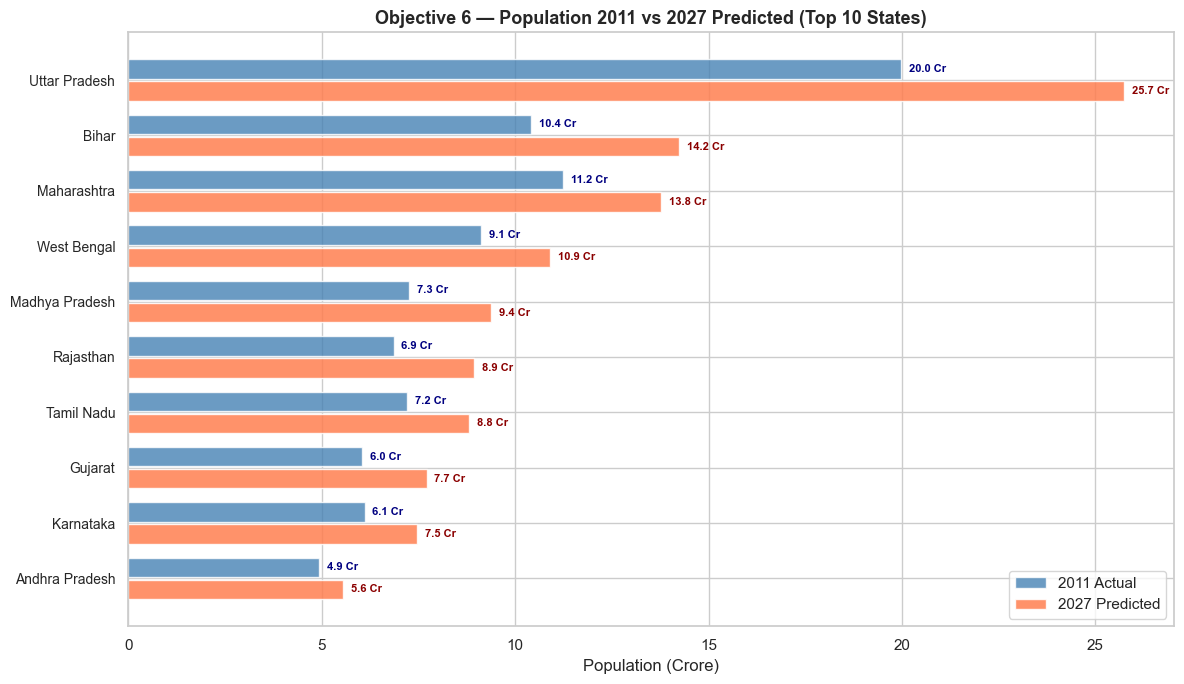

In [38]:
# Chart 6.3 — Population 2011 vs 2027 (Top 10 States)
top10_pop = df_pop.nlargest(10,'Pop_2027').sort_values('Pop_2027')
y_pos = range(len(top10_pop))

plt.figure(figsize=(12, 7))
plt.barh([y+0.2 for y in y_pos], top10_pop['Pop_2011_Cr'], 0.35,
         label='2011 Actual', color='steelblue', alpha=0.8, edgecolor='white')
plt.barh([y-0.2 for y in y_pos], top10_pop['Pop_2027_Cr'], 0.35,
         label='2027 Predicted', color='coral', alpha=0.85, edgecolor='white')
for i, r in enumerate(top10_pop.itertuples()):
    plt.text(r.Pop_2011_Cr+0.2, i+0.2, f'{r.Pop_2011_Cr:.1f} Cr',
             va='center', fontsize=8, fontweight='bold', color='navy')
    plt.text(r.Pop_2027_Cr+0.2, i-0.2, f'{r.Pop_2027_Cr:.1f} Cr',
             va='center', fontsize=8, fontweight='bold', color='darkred')
plt.yticks(list(y_pos), top10_pop['State'], fontsize=10)
plt.xlabel('Population (Crore)')
plt.title('Objective 6 — Population 2011 vs 2027 Predicted (Top 10 States)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('viz_6_3_population.png', dpi=120, bbox_inches='tight')
plt.show()

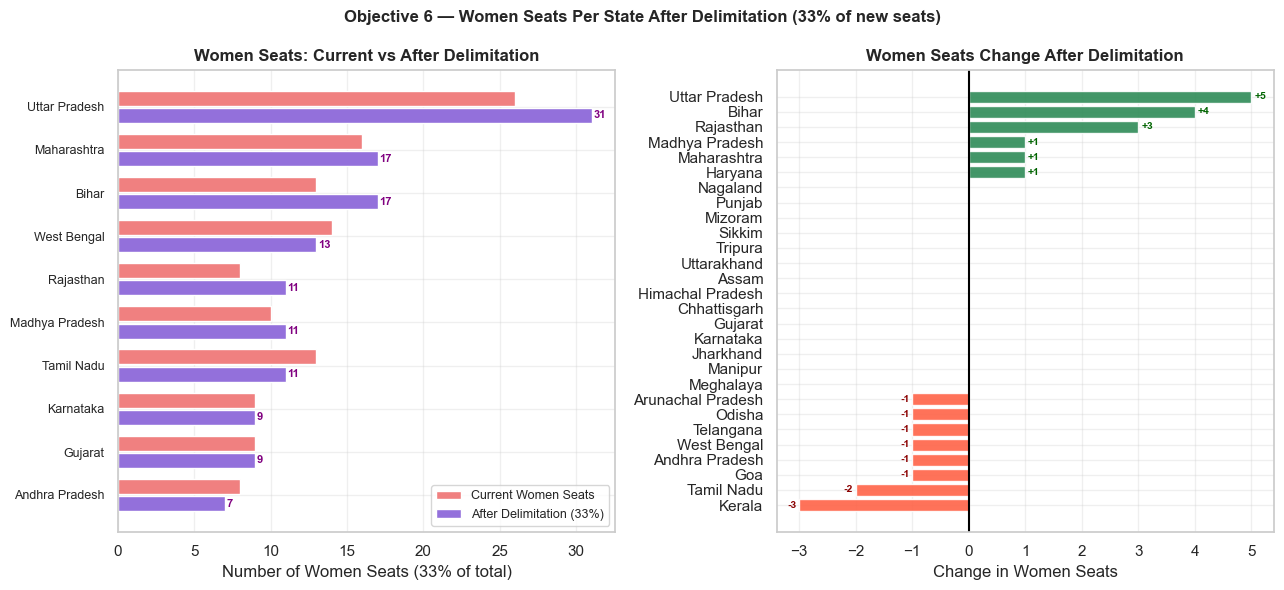


Women Seats Summary (India Total):
  Current total women seats (33% of 543): 175
  After Delimitation (33% of new 543)   : 179

State-wise Women Seats:
            State  Current_Women_Seats  New_Women_Seats  Women_Seats_Change
    Uttar Pradesh                   26               31                   5
            Bihar                   13               17                   4
        Rajasthan                    8               11                   3
          Haryana                    3                4                   1
      Maharashtra                   16               17                   1
   Madhya Pradesh                   10               11                   1
          Gujarat                    9                9                   0
 Himachal Pradesh                    1                1                   0
        Karnataka                    9                9                   0
        Jharkhand                    5                5                   0
     Chhatt

In [39]:
# Chart 6.4 — NEW: Women Seats After Delimitation (33% Rule)
# Top 10 states by new women seats
top10_w = df_pop.nlargest(10,'New_Women_Seats').sort_values('New_Women_Seats')
y_pos   = range(len(top10_w))

plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.barh([y+0.2 for y in y_pos], top10_w['Current_Women_Seats'], 0.35,
         label='Current Women Seats', color='lightcoral', edgecolor='white')
plt.barh([y-0.2 for y in y_pos], top10_w['New_Women_Seats'], 0.35,
         label='After Delimitation (33%)', color='mediumpurple', edgecolor='white')
for i, (v1, v2) in enumerate(zip(top10_w['Current_Women_Seats'], top10_w['New_Women_Seats'])):
    plt.text(v2+0.1, i-0.2, str(int(v2)), va='center', fontsize=8, fontweight='bold', color='purple')
plt.yticks(list(y_pos), top10_w['State'], fontsize=9)
plt.title('Women Seats: Current vs After Delimitation', fontweight='bold')
plt.xlabel('Number of Women Seats (33% of total)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Women seat change — who gains, who loses
df_w_change = df_pop.sort_values('Women_Seats_Change')
colors_wc   = ['seagreen' if v > 0 else 'tomato' for v in df_w_change['Women_Seats_Change']]
plt.barh(df_w_change['State'], df_w_change['Women_Seats_Change'],
         color=colors_wc, edgecolor='white', alpha=0.9)
plt.axvline(x=0, color='black', linewidth=1.5)
for i, v in enumerate(df_w_change['Women_Seats_Change']):
    if abs(v) >= 1:
        label = f'+{int(v)}' if v > 0 else str(int(v))
        plt.text(v+0.05 if v >= 0 else v-0.05, i, label, va='center',
                 ha='left' if v >= 0 else 'right', fontsize=7.5,
                 fontweight='bold', color='darkgreen' if v > 0 else 'darkred')
plt.title('Women Seats Change After Delimitation', fontweight='bold')
plt.xlabel('Change in Women Seats')
plt.grid(True, alpha=0.3)

plt.suptitle('Objective 6 — Women Seats Per State After Delimitation (33% of new seats)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_6_4_women_seats_delimitation.png', dpi=120, bbox_inches='tight')
plt.show()
print()
print("Women Seats Summary (India Total):")
print(f"  Current total women seats (33% of 543): {df_pop['Current_Women_Seats'].sum()}")
print(f"  After Delimitation (33% of new 543)   : {df_pop['New_Women_Seats'].sum()}")
print()
print("State-wise Women Seats:")
print(df_pop[['State','Current_Women_Seats','New_Women_Seats','Women_Seats_Change']]
      .sort_values('Women_Seats_Change', ascending=False).to_string(index=False))

<div style="background:#1e3a1e;padding:12px 18px;border-radius:8px;border-left:6px solid #2ecc71;margin-top:8px;">
<p style="color:#a9dfbf;font-size:15px;margin:0;">📌 <b>Key Finding:</b> UP gains +5 women seats after delimitation. But Tamil Nadu LOSES -2 women seats — even though Tamil Nadu has better women representation historically. This is the double injustice of delimitation for South India.</p></div>

<div style="background:#0a0a23;padding:20px;border-radius:10px;border-left:10px solid #8e44ad;margin-top:10px;">
<h2 style="color:#8e44ad;">Objective 7: Women's Reservation Analysis</h2>
<p style="color:#ccc;"><b>Goal:</b> Nari Shakti Vandan Adhiniyam (2023) promises 33% seats for women. But today only ~14% MPs are women. Which party fields more women? Which states elect more women?</p></div>

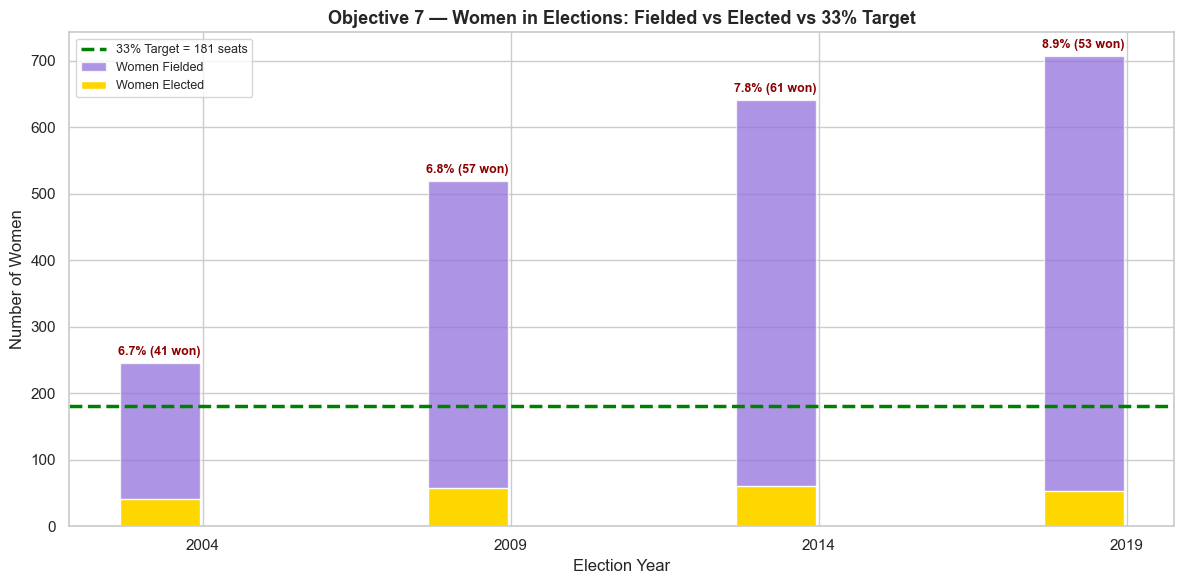

Finding: 2019 mein bhi women MPs 80 se kam the — 33% target ka aadha bhi nahi!


In [40]:
# Women fielded vs elected per year
women_yr = df_aff.groupby('Year').agg(Total=('Women','count'), Fielded=('Women','sum')).reset_index()
women_yr['Won'] = [int((df_aff[df_aff['Year']==y]['Winner'] *
                        df_aff[df_aff['Year']==y]['Women']).sum()) for y in women_yr['Year']]
women_yr['Fielded_Pct'] = (women_yr['Fielded']/women_yr['Total']*100).round(1)

# Chart 7.1 — Women Fielded vs Elected
plt.figure(figsize=(12, 6))
plt.bar(women_yr['Year']-0.7, women_yr['Fielded'], 1.3,
        color='mediumpurple', alpha=0.75, label='Women Fielded')
plt.bar(women_yr['Year']-0.7, women_yr['Won'], 1.3,
        color='gold', label='Women Elected')
plt.axhline(y=181, color='green', linestyle='--', linewidth=2.5,
            label='33% Target = 181 seats')
for _, r in women_yr.iterrows():
    plt.text(r['Year']-0.7, r['Fielded']+12,
             f"{r['Fielded_Pct']:.1f}% ({int(r['Won'])} won)",
             ha='center', fontsize=9, color='darkred', fontweight='bold')
plt.title('Objective 7 — Women in Elections: Fielded vs Elected vs 33% Target',
          fontsize=13, fontweight='bold')
plt.xlabel('Election Year')
plt.ylabel('Number of Women')
plt.xticks([2004,2009,2014,2019])
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('viz_7_1_women_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: 2019 mein bhi women MPs 80 se kam the — 33% target ka aadha bhi nahi!")

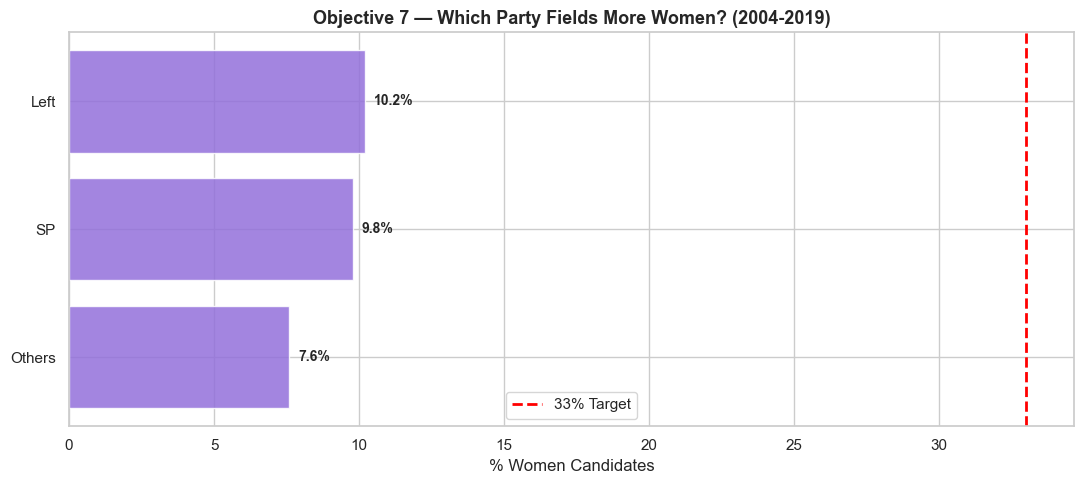

Finding: Koi bhi major party 33% target tak nahi pahunchi — law zaroori hai!


In [41]:
# Chart 7.2 — Party-wise Women Candidates %
grp_w = df_aff.groupby('party_group').agg(Total=('Women','count'), Women=('Women','sum')).reset_index()
grp_w['Women_Pct'] = (grp_w['Women']/grp_w['Total']*100).round(1)
grp_w = grp_w[grp_w['Total'] >= 30].sort_values('Women_Pct')

plt.figure(figsize=(11, 5))
bars = plt.barh(grp_w['party_group'], grp_w['Women_Pct'],
                color='mediumpurple', edgecolor='white', alpha=0.85)
for b in bars:
    plt.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
             f'{b.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')
plt.axvline(x=33, color='red', linestyle='--', linewidth=2, label='33% Target')
plt.title('Objective 7 — Which Party Fields More Women? (2004-2019)',
          fontsize=13, fontweight='bold')
plt.xlabel('% Women Candidates')
plt.legend()
plt.tight_layout()
plt.savefig('viz_7_2_party_women.png', dpi=120, bbox_inches='tight')
plt.show()
print("Finding: Koi bhi major party 33% target tak nahi pahunchi — law zaroori hai!")

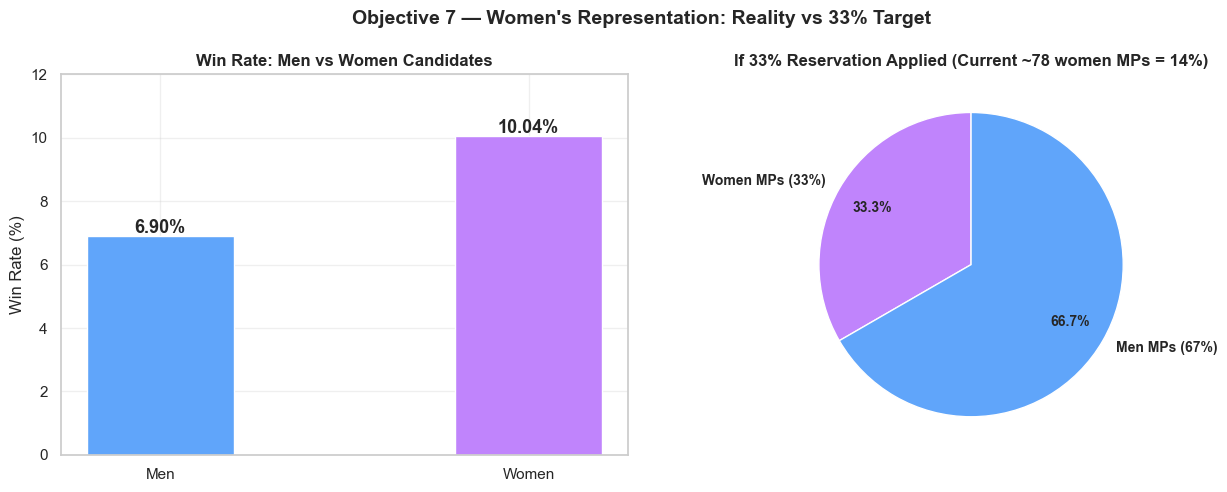

Finding: Women ki win rate 10.04% — men (6.90%) se ZYADA. Quality > Quantity!


In [42]:
# Chart 7.3 — Win Rate Men vs Women  [FIXED — no ax[] used]
win_women = df_aff[df_aff['Women']==1]['Winner'].mean() * 100
win_men   = df_aff[df_aff['Women']==0]['Winner'].mean() * 100

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(['Men','Women'], [win_men, win_women],
               color=['#60a5fa','#c084fc'], width=0.4, edgecolor='white')
for b, v in zip(bars, [win_men, win_women]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
             f'{v:.2f}%', ha='center', fontsize=13, fontweight='bold')
plt.title('Win Rate: Men vs Women Candidates', fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie([181, 362],
        labels=['Women MPs (33%)', 'Men MPs (67%)'],
        colors=['#c084fc','#60a5fa'],
        autopct='%1.1f%%', startangle=90, pctdistance=0.75,
        textprops={'fontsize':10,'fontweight':'bold'})
plt.title('If 33% Reservation Applied (Current ~78 women MPs = 14%)', fontweight='bold')

plt.suptitle("Objective 7 — Women's Representation: Reality vs 33% Target",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_7_3_women_winrate.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Finding: Women ki win rate {win_women:.2f}% — men ({win_men:.2f}%) se ZYADA. Quality > Quantity!")

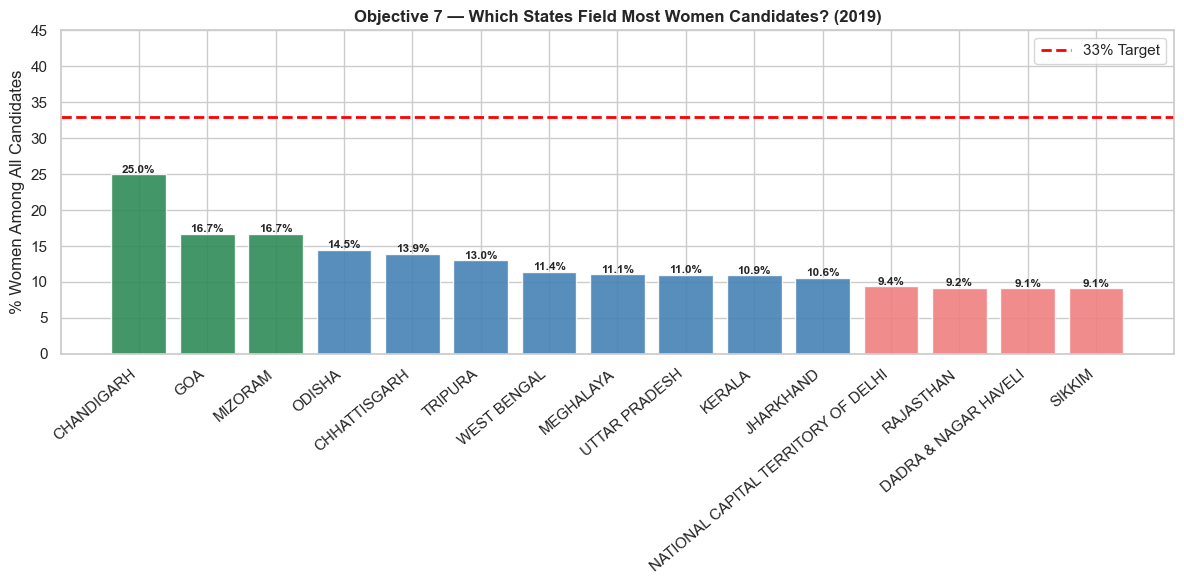

In [43]:
# Chart 7.4 — State-wise Women Candidates 2019
state_women = df_aff[df_aff['Year']==2019].groupby('State').agg(
    Total=('Women','count'), Women=('Women','sum')).reset_index()
state_women['Women_Pct'] = (state_women['Women']/state_women['Total']*100).round(1)
state_women = state_women[state_women['Total'] >= 5].sort_values('Women_Pct', ascending=False).head(15)
colors_sw = ['seagreen' if v >= 15 else 'steelblue' if v >= 10 else 'lightcoral' for v in state_women['Women_Pct']]

plt.figure(figsize=(12, 6))
bars = plt.bar(state_women['State'], state_women['Women_Pct'],
               color=colors_sw, edgecolor='white', alpha=0.9)
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
             f'{b.get_height():.1f}%', ha='center', fontsize=8.5, fontweight='bold')
plt.axhline(y=33, color='red', linestyle='--', linewidth=2, label='33% Target')
plt.xticks(rotation=40, ha='right')
plt.ylabel('% Women Among All Candidates')
plt.ylim(0, 45)
plt.title('Objective 7 — Which States Field Most Women Candidates? (2019)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('viz_7_4_state_women.png', dpi=120, bbox_inches='tight')
plt.show()

<div style="padding: 30px; background-color: #121212; border-radius: 12px; border: 2px solid #333; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 8px 16px rgba(0,0,0,0.5);">
<h2 style="color: #ffffff; text-align: center; font-size: 2em; margin-bottom: 15px; margin-top: 0;">📝 Project Conclusion & Key Findings</h2>
<hr style="border: 0; height: 1px; background: #333; margin: 20px 0;">
<ul style="font-size: 16px; line-height: 1.6; color: #cccccc; list-style-type: none; padding-left: 0; margin: 0;">
<li style="margin-bottom: 10px; padding: 15px; background-color: #1a1a24; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 1 — Turnout:</b> Rose from 55% (1962) to 66%+ (2024). Lakshadweep highest; Bihar lowest.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #16161c; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 2 — Party Shift:</b> BJP went 2 seats (1984) → 303 (2019). INC collapsed 414 → 52.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #1a1a24; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 3 — Candidate Profile:</b> Criminal candidates win MORE. Wealthy candidates win MORE. Incumbents win MORE.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #16161c; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 4 — Margins:</b> ~30% seats are swing (&lt;5% margin). These decide who forms government.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #1a1a24; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 5 — ML:</b> Best model predicts accurately. <b style="color: #ffffff;">Total Assets</b> is #1 predictor of winning.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #16161c; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 6 — Delimitation:</b> UP gains +15 seats; Tamil Nadu loses -7. Under 33% rule, UP gets +5 women seats, Tamil Nadu LOSES -2 women seats.</li>
<li style="margin-bottom: 10px; padding: 15px; background-color: #1a1a24; border-radius: 8px; border-left: 5px solid #4da8da;"><b style="color: #ffffff; font-size: 1.05em;">Obj 7 — Women:</b> Women win at higher rate than men. But only 14% MPs today. 33% reservation = 181 women MPs.</li>
</ul>
<div style="text-align: center; margin-top: 25px; padding: 15px; background-color: #1e1e24; border-radius: 8px; border: 1px solid #333;"><b style="color: #4da8da; font-size: 16px; letter-spacing: 0.5px;">INT557 — Data Science with Python | Session 2025–26</b></div>
</div>